In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
application_data = pd.read_csv("IS453 Group Assignment - Application Data.csv")
bureau_data = pd.read_csv("IS453 Group Assignment - Bureau Data.csv")
print(f"IS453 Group Assignment - Application Data.csv: {application_data.shape}")
print(f"IS453 Group Assignment - Bureau Data.csv: {bureau_data.shape}")

IS453 Group Assignment - Application Data.csv: (307511, 120)
IS453 Group Assignment - Bureau Data.csv: (1716428, 17)


In [3]:
print("count of application records:", application_data["SK_ID_CURR"].count(), "unique:", application_data["SK_ID_CURR"].nunique())
print("count of bureau records:", bureau_data["SK_ID_CURR"].count(), "unique:", bureau_data["SK_ID_CURR"].nunique())
unlinked_app = set(application_data["SK_ID_CURR"]) - set(bureau_data["SK_ID_CURR"])
linked_app = set(application_data["SK_ID_CURR"]) & set(bureau_data["SK_ID_CURR"])
print("unlinked applications:", len(unlinked_app))
print("linked applications:", len(linked_app))

count of application records: 307511 unique: 307511
count of bureau records: 1716428 unique: 305811
unlinked applications: 44020
linked applications: 263491


In [4]:
# Whether applicant ever had a car loan before
bureau_data["HAS_CAR_LOAN"] = (bureau_data["CREDIT_TYPE"] == "Car loan").astype(int)

car_loan_hist = (
    bureau_data.groupby("SK_ID_CURR", as_index=False)["HAS_CAR_LOAN"]
    .max()
    .rename(columns={"HAS_CAR_LOAN": "HAS_CAR_LOAN_HISTORY"})
)

# Merge to application data
df = application_data.merge(car_loan_hist, on="SK_ID_CURR", how="left")
df["HAS_CAR_LOAN_HISTORY"] = df["HAS_CAR_LOAN_HISTORY"].fillna(0).astype(int)

# Derive helper fields
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365.25).round(1)

# DAYS_EMPLOYED has special placeholder 365243 for missing/unknown
df["EMP_YEARS"] = (
    df["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
    .abs() / 365.25
).round(1)


# Define Applicant Filters:
group5_filter = (
    (df["NAME_CONTRACT_TYPE"] == "Cash loans") &
    (df["FLAG_OWN_CAR"] != "Y") &
    (df["HAS_CAR_LOAN_HISTORY"] != 1) &
    (df["AGE_YEARS"].between(21, 65))
)
group5 = df[group5_filter].copy()

##at this point, drop columns "DAYS_BIRTH", "DAYS_EMPLOYED", "NAME_CONTRACT_TYPE", "FLAG_OWN_CAR", "HAS_CAR_LOAN_HISTORY" and "OWN_CAR_AGE". Drop CODE_GENDER for fairness

group5.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED","NAME_CONTRACT_TYPE", "FLAG_OWN_CAR", "HAS_CAR_LOAN_HISTORY", "OWN_CAR_AGE", "CODE_GENDER"], inplace=True)

# Comparison
original_rows = len(df)
selected_rows = len(group5)

original_bad_rate = df["TARGET"].mean()
selected_bad_rate = group5["TARGET"].mean()

print("=== GROUP 5 CHECKPOINT RESULTS ===")
print(f"Original rows: {original_rows:,}")
print(f"Selected rows: {selected_rows:,}")
print(f"Original bad rate: {original_bad_rate:.4%}")
print(f"Selected bad rate: {selected_bad_rate:.4%}")
print(f"Difference in bad rate: {(selected_bad_rate - original_bad_rate):.4%}")

# Quick profile of the selected segment
print("\n=== SEGMENT PROFILE ===")
print(group5[[
    "AGE_YEARS", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "TARGET"
]].describe())

print("\nIncome type distribution:")
print(group5["NAME_INCOME_TYPE"].value_counts(dropna=False))

print("\nFamily status distribution:")
print(group5["NAME_FAMILY_STATUS"].value_counts(dropna=False))

=== GROUP 5 CHECKPOINT RESULTS ===
Original rows: 307,511
Selected rows: 173,647
Original bad rate: 8.0729%
Selected bad rate: 9.0004%
Difference in bad rate: 0.9276%

=== SEGMENT PROFILE ===
       AGE_YEARS  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY    TARGET
count  173647.00         173647.00   173647.00    173639.00 173647.00
mean       44.65         155167.95   602028.65     26935.61      0.09
std        11.79         291860.24   382756.97     13364.39      0.29
min        21.00          25650.00    45000.00      1615.50      0.00
25%        34.80         103500.00   292500.00     17374.50      0.00
50%        44.50         135000.00   526491.00     24984.00      0.00
75%        54.90         180000.00   808650.00     33511.50      0.00
max        65.00      117000000.00  4050000.00    230161.50      1.00

Income type distribution:
NAME_INCOME_TYPE
Working                 87478
Commercial associate    37309
Pensioner               36185
State servant           12655
Student       

In [5]:
# Application Data Overview
app_missing = pd.DataFrame({
    'dtype': group5.dtypes,
    'null_count': group5.isnull().sum(),
    'null_pct': (group5.isnull().sum() / len(group5) * 100).round(2),
    'nunique': group5.nunique()
}).sort_values('null_pct', ascending=False)

print(f"Shape: {group5.shape}")
print(f"\nData types:\n{group5.dtypes.value_counts()}")

print(f"\nNumerical Summary:")
display(group5.describe())

Shape: (173647, 116)

Data types:
float64    64
int64      39
object     13
Name: count, dtype: int64

Numerical Summary:


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,EMP_YEARS
count,173647.00,173647.00,173647.00,173647.00,173647.00,173639.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,73634.00,86225.00,72495.00,89774.00,58178.00,52332.00,81438.00,86933.00,87978.00,55774.00,71182.00,54931.00,87261.00,52972.00,78122.00,86225.00,72495.00,89774.00,58178.00,52332.00,81438.00,86933.00,87978.00,55774.00,71182.00,54931.00,87261.00,52972.00,78122.00,86225.00,72495.00,89774.00,58178.00,52332.00,81438.00,86933.00,87978.00,55774.00,71182.00,54931.00,87261.00,52972.00,78122.00,90683.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,148186.00,148186.00,148186.00,148186.00,148186.00,148186.00,173647.00,137453.00
mean,278124.14,0.09,0.37,155167.95,602028.65,26935.61,535027.61,0.02,-5173.83,-2995.62,1.00,0.79,0.21,1.00,0.28,0.05,2.07,2.07,2.05,12.00,0.01,0.04,0.03,0.08,0.21,0.16,0.51,0.11,0.09,0.98,0.75,0.04,0.07,0.15,0.22,0.23,0.07,0.10,0.10,0.01,0.03,0.11,0.09,0.98,0.76,0.04,0.07,0.14,0.22,0.22,0.06,0.10,0.10,0.01,0.03,0.12,0.09,0.98,0.75,0.04,0.07,0.15,0.22,0.23,0.07,0.10,0.10,0.01,0.03,0.10,1.43,0.15,1.41,0.10,-956.41,0.00,0.82,0.00,0.02,0.11,0.00,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.01,0.00,0.00,0.00,0.01,0.01,0.04,0.26,0.28,1.97,44.65,6.71
std,102748.19,0.29,0.69,291860.24,382756.97,13364.39,350949.12,0.01,3586.91,1502.46,0.00,0.41,0.40,0.02,0.45,0.22,0.89,0.51,0.50,3.27,0.12,0.21,0.18,0.27,0.41,0.37,0.21,0.11,0.08,0.06,0.11,0.07,0.13,0.10,0.14,0.16,0.08,0.09,0.11,0.05,0.07,0.11,0.08,0.06,0.11,0.07,0.13,0.10,0.14,0.16,0.08,0.10,0.11,0.05,0.07,0.11,0.08,0.06,0.11,0.07,0.13,0.10,0.14,0.16,0.08,0.09,0.11,0.05,0.07,0.10,2.33,0.45,2.31,0.37,820.15,0.01,0.39,0.01,0.12,0.31,0.00,0.19,0.07,0.00,0.06,0.00,0.01,0.05,0.01,0.10,0.02,0.09,0.02,0.02,0.00,0.08,0.11,0.21,0.89,0.92,1.90,11.79,6.70
min,100002.00,0.00,0.00,

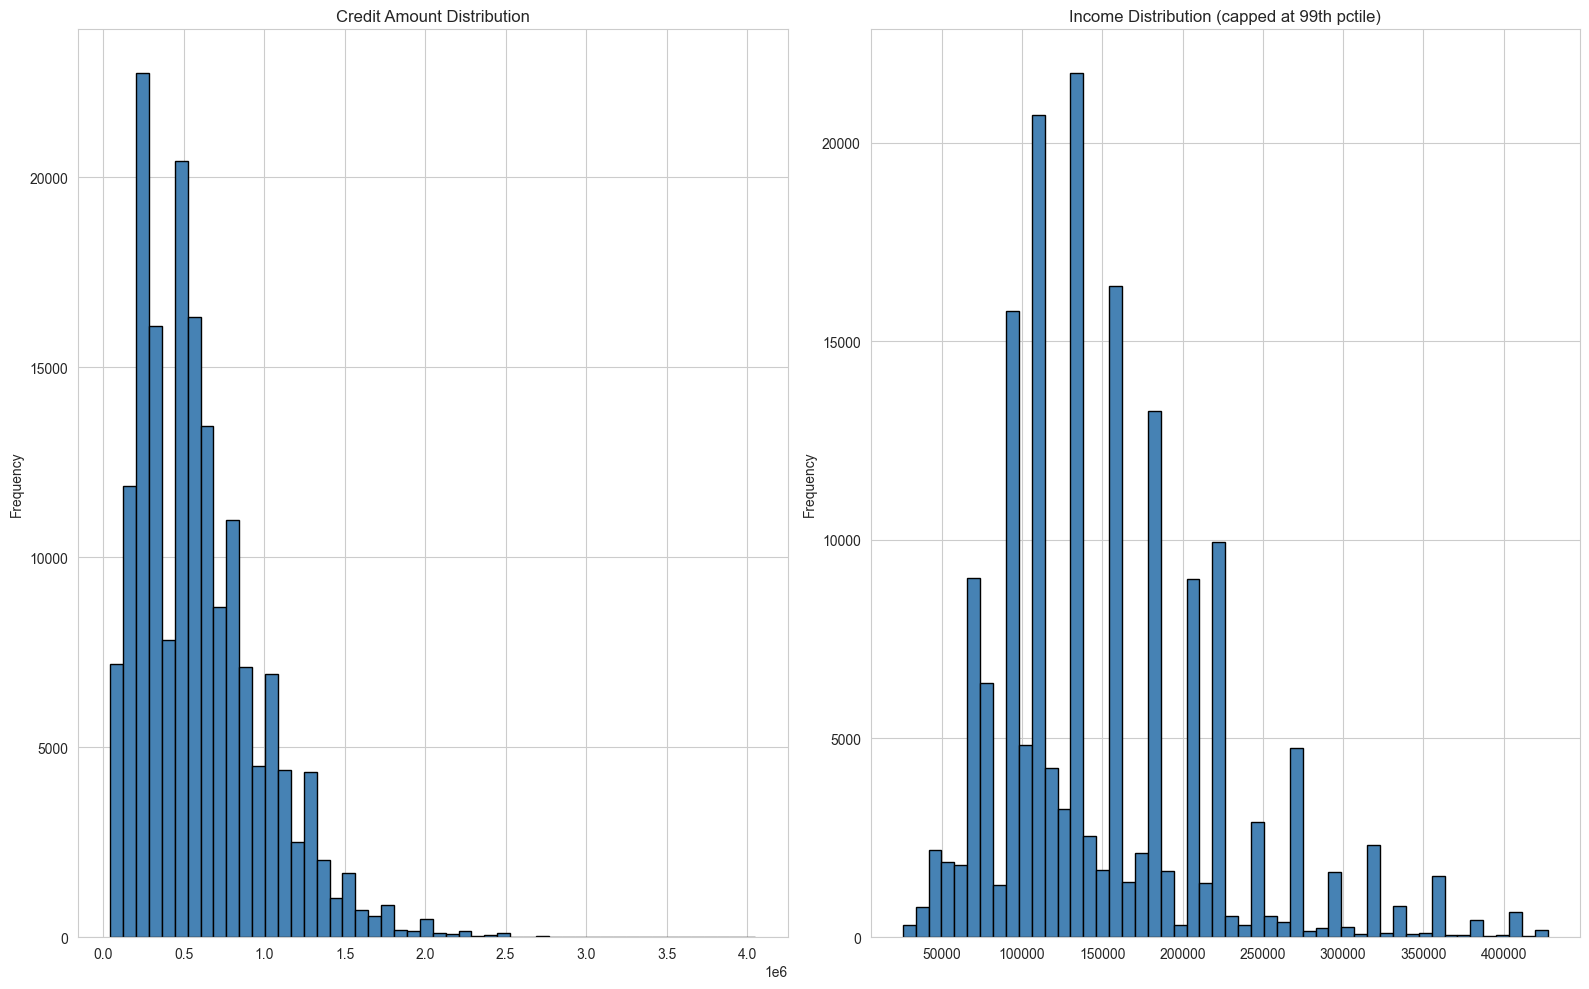

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Credit amount
group5['AMT_CREDIT'].plot(
    kind='hist', bins=50, ax=axes[0],
    color='steelblue', edgecolor='black'
)
axes[0].set_title('Credit Amount Distribution')

# Income (capped at 99th pctile for readability)
cap = group5['AMT_INCOME_TOTAL'].quantile(0.99)
group5.loc[group5['AMT_INCOME_TOTAL'] <= cap, 'AMT_INCOME_TOTAL'].plot(
    kind='hist', bins=50, ax=axes[1],
    color='steelblue', edgecolor='black'
)
axes[1].set_title('Income Distribution (capped at 99th pctile)')

plt.tight_layout()
plt.show()

In [7]:
group5.nunique().sort_values(ascending=True).head()

FLAG_DOCUMENT_10               1
FLAG_DOCUMENT_7                1
FLAG_DOCUMENT_12               1
FLAG_MOBIL                     1
LIVE_REGION_NOT_WORK_REGION    2
dtype: int64

In [8]:
##aggregate enquiry data into one column and drop the original columns

enquiry_cols = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]

# Cap QRT extreme outlier (max=261, 21.8x IQR upper bound) before aggregating
group5["AMT_REQ_CREDIT_BUREAU_QRT"] = group5["AMT_REQ_CREDIT_BUREAU_QRT"].clip(upper=50)

# Flag rows where ALL enquiry columns are NaN (14.7% of rows)
# These are structurally missing (no bureau record), not genuine zero-enquiry applicants
group5["IS_ENQUIRY_MISSING"] = group5["AMT_REQ_CREDIT_BUREAU_HOUR"].isna().astype(int)

# min_count=1 ensures all-NaN rows produce NaN (not 0)
group5["TOTAL_ENQUIRIES"] = group5[enquiry_cols].sum(axis=1, min_count=1)

group5.drop(columns=enquiry_cols, inplace=True)

##drop the columns with no variance (only 1 unique value)
group5.drop(columns=['FLAG_DOCUMENT_12','FLAG_DOCUMENT_7','FLAG_MOBIL','FLAG_DOCUMENT_10'], inplace=True)

# Calculate missing percentage for each column
missing_pct = group5.isnull().mean()

# Identify columns with more than 45% missing
cols_to_drop = missing_pct[missing_pct > 0.45].index.tolist()

print(f"Columns to drop ({len(cols_to_drop)}):")
print(cols_to_drop)

# Drop them
group5 = group5.drop(columns=cols_to_drop)
print(f"\nShape after dropping: {group5.shape}")
print(f"TOTAL_ENQUIRIES NaN count: {group5['TOTAL_ENQUIRIES'].isna().sum()}")
print(f"IS_ENQUIRY_MISSING=1 count: {group5['IS_ENQUIRY_MISSING'].sum()}")

Columns to drop (48):
['EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTA

In [9]:
group5.loc[:, group5.isnull().sum() > 0].isnull().sum()

##need to find out what to do with the missing data at this level before merging

# AMT_ANNUITY            8
# NAME_TYPE_SUITE      534 - 
# OCCUPATION_TYPE    59540 - leave as missing, unemployed or pensioners
# EMP_YEARS          36194 - leave as missing, unemployed or pensioners

AMT_ANNUITY            8
NAME_TYPE_SUITE      534
OCCUPATION_TYPE    59540
EMP_YEARS          36194
TOTAL_ENQUIRIES    25461
dtype: int64

In [10]:
group5["NAME_TYPE_SUITE"].value_counts(dropna=False)

NAME_TYPE_SUITE
Unaccompanied      140604
Family              22888
Spouse, partner      5754
Children             2101
Other_B              1108
NaN                   534
Other_A               500
Group of people       158
Name: count, dtype: int64

In [11]:
# Categorical variables — distribution & bad-rate
cat_cols = group5.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}\n")

for col in cat_cols:
    vc = group5[col].value_counts(dropna=False)
    bad_rate = group5.groupby(col, dropna=False)['TARGET'].mean()
    summary = pd.DataFrame({
        'count': vc,
        'pct': (vc / len(group5) * 100).round(2),
        'bad_rate': bad_rate
    }).sort_values('count', ascending=False)
    summary['bad_rate'] = summary['bad_rate'].apply(
        lambda x: f"{x:.2%}" if pd.notna(x) else "N/A")
    print(f"--- {col}  ({group5[col].nunique()} unique, "
          f"{group5[col].isnull().sum()} nulls) ---")
    display(summary.head(10))
    print()

Categorical columns (9): ['FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']

--- FLAG_OWN_REALTY  (2 unique, 0 nulls) ---


,count,pct,bad_rate
FLAG_OWN_REALTY,,,
Y,118463,68.22,8.80%
N,55184,31.78,9.42%



--- NAME_TYPE_SUITE  (7 unique, 534 nulls) ---


,count,pct,bad_rate
NAME_TYPE_SUITE,,,
Unaccompanied,140604,80.97,9.15%
Family,22888,13.18,8.14%
"Spouse, partner",5754,3.31,8.99%
Children,2101,1.21,8.14%
Other_B,1108,0.64,10.83%
NaN,534,0.31,5.62%
Other_A,500,0.29,9.00%
Group of people,158,0.09,9.49%



--- NAME_INCOME_TYPE  (7 unique, 0 nulls) ---


...

,count,pct,bad_rate
OCCUPATION_TYPE,,,
NaN,59540,34.29,7.08%
Laborers,29739,17.13,12.32%
Sales staff,20474,11.79,10.59%
Core staff,16005,9.22,7.20%
Managers,8426,4.85,7.31%
High skill tech staff,5971,3.44,7.29%
Medicine staff,5852,3.37,7.16%
Accountants,5360,3.09,5.52%
Drivers,5060,2.91,14.76%



--- WEEKDAY_APPR_PROCESS_START  (7 unique, 0 nulls) ---


,count,pct,bad_rate
WEEKDAY_APPR_PROCESS_START,,,
TUESDAY,30757,17.71,9.26%
WEDNESDAY,29210,16.82,9.18%
MONDAY,28671,16.51,8.52%
FRIDAY,28355,16.33,9.18%
THURSDAY,28296,16.30,8.93%
SATURDAY,19273,11.10,8.89%
SUNDAY,9085,5.23,8.93%



--- ORGANIZATION_TYPE  (58 unique, 0 nulls) ---


,count,pct,bad_rate
ORGANIZATION_TYPE,,,
XNA,36194,20.84,5.92%
Business Entity Type 3,35048,20.18,10.82%
Self-employed,20917,12.05,11.36%
Other,9379,5.40,8.53%
Medicine,7253,4.18,7.18%
Government,6074,3.50,8.05%
School,5724,3.30,6.31%
Business Entity Type 2,5701,3.28,9.31%
Kindergarten,4824,2.78,7.86%


In [12]:
####need to do categorical data cleaning (use scorecard binning)

Shape: (1716428, 18)

Data types:
float64    8
int64      6
object     3
int32      1
Name: count, dtype: int64

Missing Values:


,dtype,null_count,null_pct,nunique
AMT_ANNUITY,float64,1226791,71.47,40321
AMT_CREDIT_MAX_OVERDUE,float64,1124488,65.51,68251
DAYS_ENDDATE_FACT,float64,633653,36.92,2917
AMT_CREDIT_SUM_LIMIT,float64,591780,34.48,51726
AMT_CREDIT_SUM_DEBT,float64,257669,15.01,226537
DAYS_CREDIT_ENDDATE,float64,105553,6.15,14096
SK_ID_CURR,int64,0,0.00,305811
DAYS_CREDIT_UPDATE,int64,0,0.00,2982
CREDIT_TYPE,object,0,0.00,15
AMT_CREDIT_SUM_OVERDUE,float64,0,0.00,1616


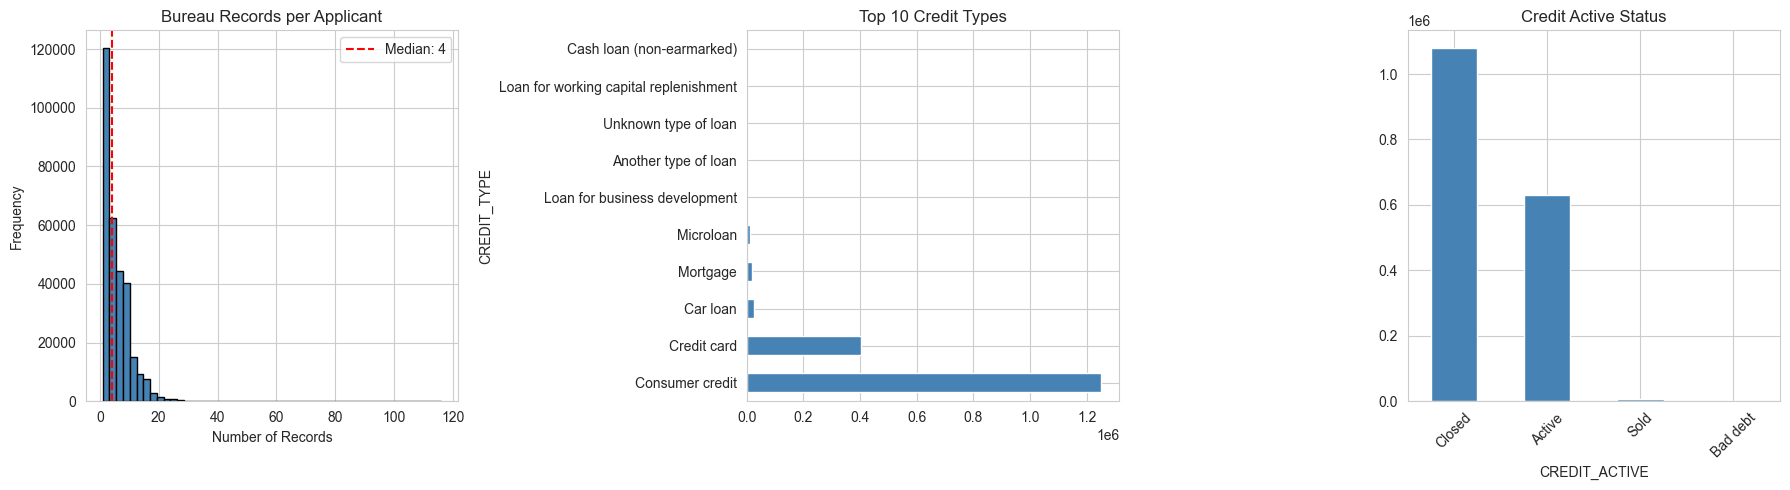


Records per applicant:
count   305811.00
mean         5.61
std          4.43
min          1.00
25%          2.00
50%          4.00
75%          8.00
max        116.00
dtype: float64

Bureau Numerical Summary:


,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,HAS_CAR_LOAN
count,1716428.00,1716428.00,1716428.00,1716428.00,1610875.00,1082775.00,591940.00,1716428.00,1716415.00,1458759.00,1124648.00,1716428.00,1716428.00,489637.00,1716428.00
mean,278214.93,5924434.49,-1142.11,0.82,510.52,-1017.44,3825.42,0.01,354994.59,137085.12,6229.51,37.91,-593.75,15712.76,0.02
std,102938.56,532265.73,795.16,36.54,4994.22,714.01,206031.61,0.10,1149811.34,677401.13,45032.03,5937.65,720.75,325826.95,0.13
min,100001.00,5000000.00,-2922.00,0.00,-42060.00,-42023.00,0.00,0.00,0.00,-4705600.32,-586406.11,0.00,-41947.00,0.00,0.00
25%,188866.75,5463953.75,-1666.00,0.00,-1138.00,-1489.00,0.00,0.00,51300.00,0.00,0.00,0.00,-908.00,0.00,0.00
50%,278055.00,5926303.50,-987.00,0.00,-330.00,-897.00,0.00,0.00,125518.50,0.00,0.00,0.00,-395.00,0.00,0.00
75%,367426.00,6385681.25,-474.00,0.00,474.00,-425.00,0.00,0.00,315000.00,40153.50,0.00,0.00,-33.00,13500.00,0.00
max,456255.00,6843457.00,0.00,2792.00,31199.00,0.00,115987185.00,9.00,585000000.00,170100000.00,4705600.32,3756681.00,372.00,118453423.50,1.00


In [13]:
# Bureau Data Overview
bureau_missing = pd.DataFrame({
    'dtype': bureau_data.dtypes,
    'null_count': bureau_data.isnull().sum(),
    'null_pct': (bureau_data.isnull().sum() / len(bureau_data) * 100).round(2),
    'nunique': bureau_data.nunique()
}).sort_values('null_pct', ascending=False)

print(f"Shape: {bureau_data.shape}")
print(f"\nData types:\n{bureau_data.dtypes.value_counts()}")
print(f"\nMissing Values:")
display(bureau_missing)

# Distributions
records_per_app = bureau_data.groupby('SK_ID_CURR').size()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

records_per_app.plot(kind='hist', bins=50, ax=axes[0],
                     color='steelblue', edgecolor='black')
axes[0].set_title('Bureau Records per Applicant')
axes[0].set_xlabel('Number of Records')
axes[0].axvline(records_per_app.median(), color='red', linestyle='--',
                label=f'Median: {records_per_app.median():.0f}')
axes[0].legend()

bureau_data['CREDIT_TYPE'].value_counts().head(10).plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Credit Types')

bureau_data['CREDIT_ACTIVE'].value_counts().plot(
    kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Credit Active Status')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nRecords per applicant:\n{records_per_app.describe()}")
print(f"\nBureau Numerical Summary:")
display(bureau_data.describe())

In [14]:
bureau_data['DAYS_CREDIT_ENDDATE'] = np.where(
    bureau_data['DAYS_CREDIT_ENDDATE'] < -16294,
    np.nan,
    bureau_data['DAYS_CREDIT_ENDDATE']
)
bureau_data['DAYS_ENDDATE_FACT'] = np.where(
    bureau_data['DAYS_ENDDATE_FACT'] < -42022,
    np.nan,
    bureau_data['DAYS_ENDDATE_FACT']
)
# Cap extreme past values AND future dates (positive = updated after application date = leakage)
bureau_data['DAYS_CREDIT_UPDATE'] = np.where(
    bureau_data['DAYS_CREDIT_UPDATE'] < -41850, np.nan,
    np.where(bureau_data['DAYS_CREDIT_UPDATE'] > 0, np.nan,
             bureau_data['DAYS_CREDIT_UPDATE'])
)

##0.49% of AMT_CREDIT_SUM_DEBT values are below 0. This is likely due to overpayment or credit balance. Since we will be doing sums and averages later, we can ignore this for now and floor at 0 after aggregation.
##0.02% of AMT_CREDIT_SUM_LIMIT are below 0, which is likely data error. We can set these to NaN as well. we can change this later.
bureau_data['AMT_CREDIT_SUM_LIMIT'] = np.where(
    bureau_data['AMT_CREDIT_SUM_LIMIT'] < 0,
    np.nan,
    bureau_data['AMT_CREDIT_SUM_LIMIT']
)

In [15]:
bureau_data.describe()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,HAS_CAR_LOAN
count,1716428.00,1716428.00,1716428.00,1716428.00,1610729.00,1082774.00,591940.00,1716428.00,1716415.00,1458759.00,1124297.00,1716428.00,1716316.00,489637.00,1716428.00
mean,278214.93,5924434.49,-1142.11,0.82,514.17,-1017.40,3825.42,0.01,354994.59,137085.12,6238.88,37.91,-591.47,15712.76,0.02
std,102938.56,532265.73,795.16,36.54,4979.26,712.92,206031.61,0.10,1149811.34,677401.13,45022.33,5937.65,651.99,325826.95,0.13
min,100001.00,5000000.00,-2922.00,0.00,-5150.00,-3042.00,0.00,0.00,0.00,-4705600.32,0.00,0.00,-2917.00,0.00,0.00
25%,188866.75,5463953.75,-1666.00,0.00,-1137.00,-1489.00,0.00,0.00,51300.00,0.00,0.00,0.00,-908.00,0.00,0.00
50%,278055.00,5926303.50,-987.00,0.00,-330.00,-897.00,0.00,0.00,125518.50,0.00,0.00,0.00,-395.00,0.00,0.00
75%,367426.00,6385681.25,-474.00,0.00,474.00,-425.00,0.00,0.00,315000.00,40153.50,0.00,0.00,-33.00,13500.00,0.00
max,456255.00,6843457.00,0.00,2792.00,31199.00,0.00,115987185.00,9.00,585000000.00,170100000.00,4705600.32,3756681.00,0.00,118453423.50,1.00


In [16]:
# ── Binary flags before aggregation ──
bureau_data['BUREAU_IS_ACTIVE']   = (bureau_data['CREDIT_ACTIVE'] == 'Active').astype(int)
bureau_data['BUREAU_IS_CLOSED']   = (bureau_data['CREDIT_ACTIVE'] == 'Closed').astype(int)
bureau_data['BUREAU_IS_BAD_SOLD'] = (bureau_data['CREDIT_ACTIVE'].isin(['Sold', 'Bad debt'])).astype(int)

# ── Collapse rare credit types ──
top_types = ['Consumer credit', 'Credit card', 'Car loan', 'Mortgage', 'Microloan']
bureau_data['CREDIT_TYPE_GROUPED'] = bureau_data['CREDIT_TYPE'].apply(
    lambda x: x if x in top_types else 'Other'
)

# ── Main aggregation ──
bureau_agg = bureau_data.groupby('SK_ID_CURR').agg(
    # ── Record count ──
    BUREAU_RECORD_COUNT        = ('SK_ID_BUREAU', 'count'),

    # ── Credit active status ──
    BUREAU_ACTIVE_COUNT        = ('BUREAU_IS_ACTIVE', 'sum'),
    BUREAU_CLOSED_COUNT        = ('BUREAU_IS_CLOSED', 'sum'),
    BUREAU_BAD_SOLD_COUNT      = ('BUREAU_IS_BAD_SOLD', 'sum'),  # strong risk signal

    # ── Days credit (when credit was reported, negative = past) ──
    BUREAU_OLDEST_CREDIT       = ('DAYS_CREDIT', 'min'),   # most negative = oldest
    BUREAU_RECENT_CREDIT       = ('DAYS_CREDIT', 'max'),   # closest to 0 = most recent
    BUREAU_AVG_CREDIT_AGE      = ('DAYS_CREDIT', 'mean'),

    # ── Days overdue ──
    BUREAU_MAX_OVERDUE_DAYS    = ('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_MEAN_OVERDUE_DAYS   = ('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_SUM_OVERDUE_DAYS    = ('CREDIT_DAY_OVERDUE', 'sum'),

    # ── Credit end date ──
    BUREAU_EARLIEST_ENDDATE    = ('DAYS_CREDIT_ENDDATE', 'min'),
    BUREAU_LATEST_ENDDATE      = ('DAYS_CREDIT_ENDDATE', 'max'),

    # ── Actual end date (only for closed credits) ──
    BUREAU_EARLIEST_CLOSED     = ('DAYS_ENDDATE_FACT', 'min'),
    BUREAU_LATEST_CLOSED       = ('DAYS_ENDDATE_FACT', 'max'),

    # ── Max overdue amount ever ──
    BUREAU_MAX_AMT_OVERDUE     = ('AMT_CREDIT_MAX_OVERDUE', 'max'),
    BUREAU_MEAN_AMT_OVERDUE    = ('AMT_CREDIT_MAX_OVERDUE', 'mean'),
    BUREAU_SUM_AMT_OVERDUE     = ('AMT_CREDIT_MAX_OVERDUE', 'sum'),

    # ── Credit prolongations ──
    BUREAU_TOTAL_PROLONGATIONS = ('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_MAX_PROLONGATIONS   = ('CNT_CREDIT_PROLONG', 'max'),

    # ── Total credit amount ──
    BUREAU_TOTAL_CREDIT        = ('AMT_CREDIT_SUM', 'sum'),
    BUREAU_MAX_CREDIT          = ('AMT_CREDIT_SUM', 'max'),
    BUREAU_MEAN_CREDIT         = ('AMT_CREDIT_SUM', 'mean'),

    # ── Outstanding debt ──
    BUREAU_TOTAL_DEBT          = ('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_MAX_DEBT            = ('AMT_CREDIT_SUM_DEBT', 'max'),
    BUREAU_MEAN_DEBT           = ('AMT_CREDIT_SUM_DEBT', 'mean'),

    # ── Credit limit ──
    BUREAU_TOTAL_LIMIT         = ('AMT_CREDIT_SUM_LIMIT', 'sum'),
    BUREAU_MAX_LIMIT           = ('AMT_CREDIT_SUM_LIMIT', 'max'),

    # ── Current overdue amount ──
    BUREAU_TOTAL_AMT_OVERDUE   = ('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    BUREAU_MAX_AMT_OVERDUE_NOW = ('AMT_CREDIT_SUM_OVERDUE', 'max'),

    # ── Credit type diversity ──
    BUREAU_CREDIT_TYPE_COUNT   = ('CREDIT_TYPE_GROUPED', 'nunique'),

    # ── Days since last update ──
    BUREAU_LAST_UPDATE         = ('DAYS_CREDIT_UPDATE', 'max'),
    BUREAU_OLDEST_UPDATE       = ('DAYS_CREDIT_UPDATE', 'min'),

    # ── Annuity ──
    BUREAU_TOTAL_ANNUITY       = ('AMT_ANNUITY', 'sum'),
    BUREAU_MAX_ANNUITY         = ('AMT_ANNUITY', 'max'),
    BUREAU_MEAN_ANNUITY        = ('AMT_ANNUITY', 'mean'),
).reset_index()

# ── Floor negative debt values to 0 (overpayment / credit balance artefacts) ──
# Cell 13 comment promised this but the code was never written.
# Negative debt flows into BUREAU_DEBT_UTIL and other ratios if left unchecked.
bureau_agg["BUREAU_TOTAL_DEBT"] = bureau_agg["BUREAU_TOTAL_DEBT"].clip(lower=0)
bureau_agg["BUREAU_MEAN_DEBT"]  = bureau_agg["BUREAU_MEAN_DEBT"].clip(lower=0)

# ── Credit type pivot (collapsed) ──
credit_type_pivot = bureau_data.groupby('SK_ID_CURR')['CREDIT_TYPE_GROUPED'] \
    .value_counts().unstack(fill_value=0)
credit_type_pivot.columns = [
    f'BUREAU_TYPE_{c.replace(" ", "_").upper()}'
    for c in credit_type_pivot.columns]

# ── Final merge ──
bureau_agg = bureau_agg \
    .merge(credit_type_pivot.reset_index(), on='SK_ID_CURR', how='left')
# All zero-fills
fill_zero = [
    'BUREAU_MAX_AMT_OVERDUE', 'BUREAU_MEAN_AMT_OVERDUE',
    'BUREAU_MAX_DEBT', 'BUREAU_MEAN_DEBT',
    'BUREAU_MAX_LIMIT', 'BUREAU_MAX_ANNUITY', 'BUREAU_MEAN_ANNUITY',
    'BUREAU_MAX_CREDIT', 'BUREAU_MEAN_CREDIT',
]
bureau_agg[fill_zero] = bureau_agg[fill_zero].fillna(0)

# Conditional — flag then fill
bureau_agg['HAS_NO_CLOSED_CREDIT'] = bureau_agg['BUREAU_EARLIEST_CLOSED'].isna().astype(int)
bureau_agg['HAS_NO_ENDDATE']        = bureau_agg['BUREAU_EARLIEST_ENDDATE'].isna().astype(int)

bureau_agg.drop("BUREAU_TYPE_CAR_LOAN", axis=1, inplace=True)
print(f"Bureau aggregated shape: {bureau_agg.shape}")
print(f"Columns: {bureau_agg.columns.tolist()}")

Bureau aggregated shape: (305811, 43)
Columns: ['SK_ID_CURR', 'BUREAU_RECORD_COUNT', 'BUREAU_ACTIVE_COUNT', 'BUREAU_CLOSED_COUNT', 'BUREAU_BAD_SOLD_COUNT', 'BUREAU_OLDEST_CREDIT', 'BUREAU_RECENT_CREDIT', 'BUREAU_AVG_CREDIT_AGE', 'BUREAU_MAX_OVERDUE_DAYS', 'BUREAU_MEAN_OVERDUE_DAYS', 'BUREAU_SUM_OVERDUE_DAYS', 'BUREAU_EARLIEST_ENDDATE', 'BUREAU_LATEST_ENDDATE', 'BUREAU_EARLIEST_CLOSED', 'BUREAU_LATEST_CLOSED', 'BUREAU_MAX_AMT_OVERDUE', 'BUREAU_MEAN_AMT_OVERDUE', 'BUREAU_SUM_AMT_OVERDUE', 'BUREAU_TOTAL_PROLONGATIONS', 'BUREAU_MAX_PROLONGATIONS', 'BUREAU_TOTAL_CREDIT', 'BUREAU_MAX_CREDIT', 'BUREAU_MEAN_CREDIT', 'BUREAU_TOTAL_DEBT', 'BUREAU_MAX_DEBT', 'BUREAU_MEAN_DEBT', 'BUREAU_TOTAL_LIMIT', 'BUREAU_MAX_LIMIT', 'BUREAU_TOTAL_AMT_OVERDUE', 'BUREAU_MAX_AMT_OVERDUE_NOW', 'BUREAU_CREDIT_TYPE_COUNT', 'BUREAU_LAST_UPDATE', 'BUREAU_OLDEST_UPDATE', 'BUREAU_TOTAL_ANNUITY', 'BUREAU_MAX_ANNUITY', 'BUREAU_MEAN_ANNUITY', 'BUREAU_TYPE_CONSUMER_CREDIT', 'BUREAU_TYPE_CREDIT_CARD', 'BUREAU_TYPE_MICROLOAN'

In [17]:
merged_df = group5.merge(bureau_agg, on='SK_ID_CURR', how='left')

# Flag borrowers with bureau history but NO closed credits (all-active portfolio).
# BUREAU_EARLIEST_CLOSED has 45,964 NaNs vs 26,879 thin-file applicants —
# the extra 19,085 are active-only borrowers, a fundamentally different risk profile
# from thin-file applicants (no bureau record at all).
merged_df["IS_ALL_ACTIVE_BUREAU"] = (
    merged_df["BUREAU_RECORD_COUNT"].notna() &
    merged_df["BUREAU_EARLIEST_CLOSED"].isna()
).astype(int)

print(f"\nMerged DataFrame: {merged_df.shape}")
print(f"With bureau data:    {merged_df['BUREAU_RECORD_COUNT'].notna().sum():,}")
print(f"Without bureau data: {merged_df['BUREAU_RECORD_COUNT'].isna().sum():,}")
print(f"All-active bureau:   {merged_df['IS_ALL_ACTIVE_BUREAU'].sum():,}")


Merged DataFrame: (173647, 103)
With bureau data:    146,768
Without bureau data: 26,879
All-active bureau:   19,085


In [18]:
merged_missing = pd.DataFrame({
    'dtype': merged_df.dtypes,
    'null_count': merged_df.isnull().sum(),
    'null_pct': (merged_df.isnull().sum() / len(merged_df) * 100).round(2),
    'nunique': merged_df.nunique()
}).sort_values('null_pct', ascending=False)


print(f"\nData types:\n{merged_df.dtypes.value_counts()}")
print(f"\nMissing Values:")
pd.set_option('display.max_rows', None)
display(merged_missing[merged_missing["null_count"]>0].sort_values("null_count", ascending=False))



Data types:
float64    57
int64      35
object      9
int32       2
Name: count, dtype: int64

Missing Values:


,dtype,null_count,null_pct,nunique
OCCUPATION_TYPE,object,59540,34.29,18
BUREAU_EARLIEST_CLOSED,float64,45964,26.47,2892
BUREAU_LATEST_CLOSED,float64,45964,26.47,2771
EMP_YEARS,float64,36194,20.84,453
BUREAU_EARLIEST_ENDDATE,float64,28171,16.22,5963
BUREAU_LATEST_ENDDATE,float64,28171,16.22,11350
BUREAU_OLDEST_UPDATE,float64,26880,15.48,2887
BUREAU_LAST_UPDATE,float64,26880,15.48,2529
BUREAU_MAX_LIMIT,float64,26879,15.48,19502
BUREAU_TYPE_CONSUMER_CREDIT,float64,26879,15.48,51


Columns with outliers: 29 / 39


,column,total,outlier_count,outlier_pct,lower_bound,upper_bound,min,max
27,BUREAU_MEAN_AMT_OVERDUE,146768,35487,24.18,-101.25,135.00,0.00,47406123.00
28,BUREAU_SUM_AMT_OVERDUE,146768,35427,24.14,-277.16,369.54,0.00,94812246.00
26,BUREAU_MAX_AMT_OVERDUE,146768,35428,24.14,-272.30,363.06,0.00,94812246.00
35,BUREAU_LAST_UPDATE,146767,25041,17.06,-193.00,129.00,-2910.00,0.00
23,BUREAU_LATEST_ENDDATE,145476,23828,16.38,-4581.00,6304.00,-2858.00,31199.00
30,BUREAU_MAX_CREDIT,146768,7192,4.90,-1595475.00,2494800.00,0.00,135000000.00
34,BUREAU_MEAN_DEBT,146768,7193,4.90,-343955.60,458607.46,0.00,33902743.50
33,BUREAU_MAX_DEBT,146768,6824,4.65,-1164796.88,1553062.50,-15846.98,59637690.00
32,BUREAU_TOTAL_DEBT,146768,6703,4.57,-1611183.86,2148245.14,0.00,59637690.00
31,BUREAU_MEAN_CREDIT,146768,6450,4.39,-538355.68,937840.04,0.00,54040833.22


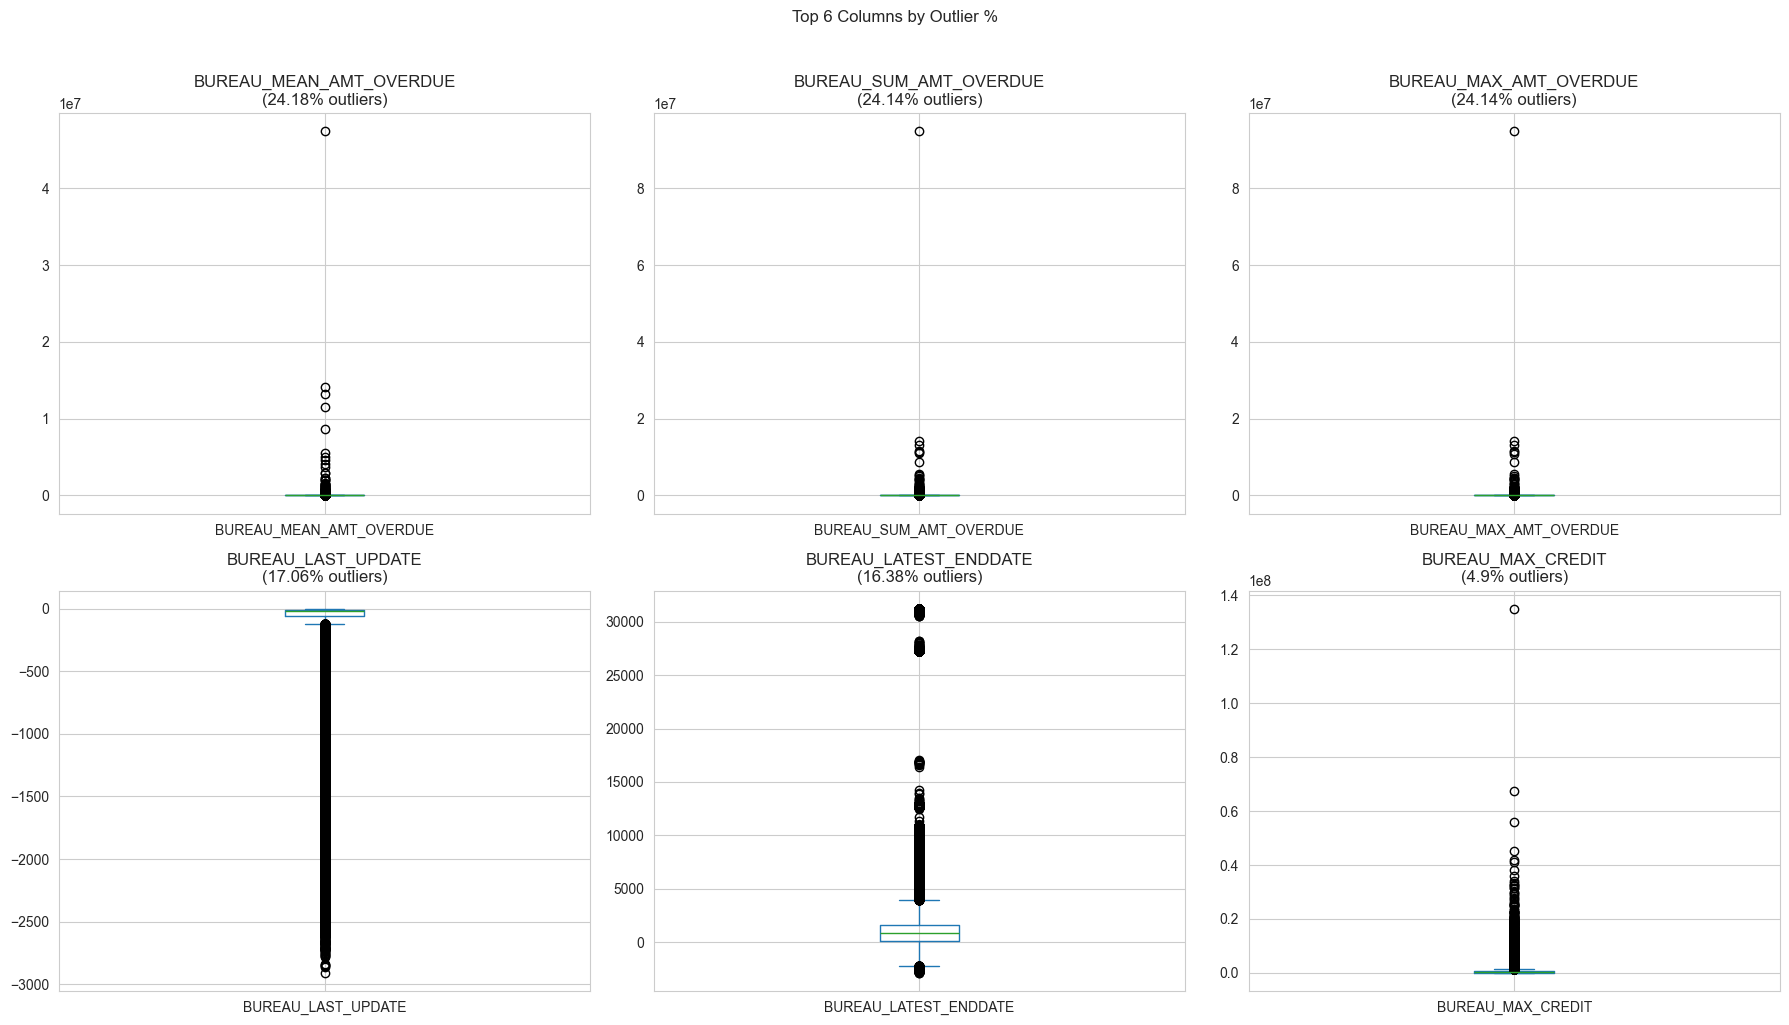


=== PROPOSED OUTLIER TREATMENT ===
Valid outliers (domain-expected extreme values):
  - AMT_INCOME_TOTAL: high incomes are valid → cap at 99th pctile
  - DAYS_EMPLOYED: 365243 placeholder already replaced with NaN
  - CNT_CHILDREN: large families valid → cap at 5+
Invalid outliers (likely data errors):
  - Negative values in amount fields → flag for review
  - Illogical DAYS values → review and treat


In [19]:
# Outlier detection — IQR method
num_cols_eda = merged_df.select_dtypes(include='number').columns.tolist()
# Skip zero-inflated columns from outlier capping
# A column is zero-inflated if its 75th percentile is 0
zero_inflated = [col for col in num_cols_eda 
                 if merged_df[col].quantile(0.75) == 0]
num_cols_eda = [c for c in num_cols_eda 
                if c not in ['SK_ID_CURR', 'TARGET']
                and c not in zero_inflated
                and merged_df[c].nunique() > 10]

outlier_rows = []
for col in num_cols_eda:
    data = merged_df[col].dropna()
    if len(data) == 0:
        continue
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    outlier_rows.append({
        'column': col,
        'total': len(data),
        'outlier_count': n_out,
        'outlier_pct': round(n_out / len(data) * 100, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'min': round(data.min(), 2),
        'max': round(data.max(), 2),
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values('outlier_pct', ascending=False)
print(f"Columns with outliers: "
      f"{(outlier_df['outlier_count'] > 0).sum()} / {len(outlier_df)}")
display(outlier_df.head(30))

# Box-plots for top-6 outlier columns
top6 = outlier_df.head(6)['column'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(top6):
    ax = axes[i // 3, i % 3]
    merged_df[col].dropna().plot(kind='box', ax=ax)
    pct = outlier_df.loc[outlier_df['column'] == col, 'outlier_pct'].values[0]
    ax.set_title(f'{col}\n({pct}% outliers)')
plt.suptitle('Top 6 Columns by Outlier %', y=1.02)
plt.tight_layout()
plt.show()

print("\n=== PROPOSED OUTLIER TREATMENT ===")
print("Valid outliers (domain-expected extreme values):")
print("  - AMT_INCOME_TOTAL: high incomes are valid → cap at 99th pctile")
print("  - DAYS_EMPLOYED: 365243 placeholder already replaced with NaN")
print("  - CNT_CHILDREN: large families valid → cap at 5+")
print("Invalid outliers (likely data errors):")
print("  - Negative values in amount fields → flag for review")
print("  - Illogical DAYS values → review and treat")

In [20]:
##deal with outlier columns here - find out what are invalid outliers!

In [21]:
# Select numerical columns for VIF
vif_candidates = merged_df.select_dtypes(include='number').columns.tolist()
vif_candidates = [c for c in vif_candidates
                  if c not in ['SK_ID_CURR', 'TARGET']
                  and merged_df[c].nunique() > 1]

# Use top-30 by TARGET correlation (VIF is O(p²n))
target_corr_abs = merged_df[vif_candidates + ['TARGET']].corr()['TARGET'] \
    .drop('TARGET').abs().sort_values(ascending=False)
vif_candidates = target_corr_abs.head(30).index.tolist()
print(f"VIF on top 30 features (by |corr with TARGET|)")

# Sample for speed & standardise
sample = merged_df[vif_candidates].sample(
    min(10_000, len(merged_df)), random_state=42).dropna()
sample_std = (sample - sample.mean()) / sample.std()
sample_std = sample_std.dropna(axis=1)           # drop any all-NaN cols

vif_results = pd.DataFrame({
    'feature': sample_std.columns,
    'VIF': [variance_inflation_factor(sample_std.values, i)
            for i in range(sample_std.shape[1])]
}).sort_values('VIF', ascending=False)

print("\nVIF  (>5 = moderate,  >10 = severe multicollinearity)")
display(vif_results)

high_vif = vif_results[vif_results['VIF'] > 5]
print(f"\nFeatures with VIF > 5: {len(high_vif)}")
if len(high_vif) > 0:
    display(high_vif)

VIF on top 30 features (by |corr with TARGET|)

VIF  (>5 = moderate,  >10 = severe multicollinearity)


,feature,VIF
21,AMT_CREDIT,36.45
15,AMT_GOODS_PRICE,36.36
9,REGION_RATING_CLIENT_W_CITY,10.51
10,REGION_RATING_CLIENT,10.46
0,BUREAU_AVG_CREDIT_AGE,9.69
8,BUREAU_EARLIEST_CLOSED,8.45
3,BUREAU_OLDEST_CREDIT,8.45
6,REG_CITY_NOT_WORK_CITY,8.23
16,LIVE_CITY_NOT_WORK_CITY,6.56
5,BUREAU_OLDEST_UPDATE,4.54



Features with VIF > 5: 9


,feature,VIF
21,AMT_CREDIT,36.45
15,AMT_GOODS_PRICE,36.36
9,REGION_RATING_CLIENT_W_CITY,10.51
10,REGION_RATING_CLIENT,10.46
0,BUREAU_AVG_CREDIT_AGE,9.69
8,BUREAU_EARLIEST_CLOSED,8.45
3,BUREAU_OLDEST_CREDIT,8.45
6,REG_CITY_NOT_WORK_CITY,8.23
16,LIVE_CITY_NOT_WORK_CITY,6.56


In [22]:
# Correlation analysis on GROUP 5 data
num_cols = merged_df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'SK_ID_CURR']

corr_matrix = merged_df[num_cols].corr()

# 1) Correlation with TARGET
target_corr = corr_matrix['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
print("Top 20 features correlated with TARGET:")
display(target_corr.head(20))

Top 20 features correlated with TARGET:


BUREAU_AVG_CREDIT_AGE         0.09
AGE_YEARS                     0.09
EMP_YEARS                     0.08
BUREAU_OLDEST_CREDIT          0.08
BUREAU_ACTIVE_COUNT           0.07
BUREAU_OLDEST_UPDATE          0.07
REG_CITY_NOT_WORK_CITY        0.06
DAYS_LAST_PHONE_CHANGE        0.06
BUREAU_EARLIEST_CLOSED        0.06
REGION_RATING_CLIENT_W_CITY   0.06
REGION_RATING_CLIENT          0.06
DAYS_ID_PUBLISH               0.06
FLAG_EMP_PHONE                0.06
HAS_NO_CLOSED_CREDIT          0.05
BUREAU_RECENT_CREDIT          0.05
REG_CITY_NOT_LIVE_CITY        0.05
DAYS_REGISTRATION             0.05
AMT_GOODS_PRICE               0.04
IS_ALL_ACTIVE_BUREAU          0.04
LIVE_CITY_NOT_WORK_CITY       0.04
Name: TARGET, dtype: float64

In [23]:
# 2) Highly-correlated feature pairs (|r| > 0.7)
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [
    (col, idx, upper_tri.loc[idx, col])
    for col in upper_tri.columns for idx in upper_tri.index
    if abs(upper_tri.loc[idx, col]) > 0.7
]
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"\nHighly correlated feature pairs (|r| > 0.7): {len(high_corr_pairs)}")
high_corr_df = pd.DataFrame(
    high_corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlation'])
display(high_corr_df.head(30))


Highly correlated feature pairs (|r| > 0.7): 39


,Feature_1,Feature_2,Correlation
0,IS_ALL_ACTIVE_BUREAU,HAS_NO_CLOSED_CREDIT,1.00
1,BUREAU_SUM_AMT_OVERDUE,BUREAU_MAX_AMT_OVERDUE,1.00
2,OBS_60_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,1.00
3,BUREAU_MAX_PROLONGATIONS,BUREAU_TOTAL_PROLONGATIONS,0.99
4,BUREAU_SUM_OVERDUE_DAYS,BUREAU_MAX_OVERDUE_DAYS,0.99
5,AMT_GOODS_PRICE,AMT_CREDIT,0.99
6,BUREAU_MAX_DEBT,BUREAU_TOTAL_DEBT,0.97
7,BUREAU_MEAN_AMT_OVERDUE,BUREAU_MAX_AMT_OVERDUE,0.97
8,BUREAU_SUM_AMT_OVERDUE,BUREAU_MEAN_AMT_OVERDUE,0.96
9,BUREAU_MAX_LIMIT,BUREAU_TOTAL_LIMIT,0.96


KJ Code

In [ ]:
def calculate_iv(df, feature, target, bins=10):
    temp = df[[feature, target]].copy()

    # Handle missing
    temp[feature] = temp[feature].fillna(-999)

    # Bin numeric variables
    if pd.api.types.is_numeric_dtype(temp[feature]):
        try:
            temp['bin'] = pd.qcut(temp[feature], bins, duplicates='drop')
        except:
            temp['bin'] = temp[feature]
    else:
        temp['bin'] = temp[feature]

    grouped = temp.groupby('bin')[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']

    grouped['bad_dist'] = grouped['bad'] / grouped['bad'].sum()
    grouped['good_dist'] = grouped['good'] / grouped['good'].sum()

    grouped['woe'] = np.log((grouped['good_dist'] + 1e-6) / (grouped['bad_dist'] + 1e-6))
    grouped['iv'] = (grouped['good_dist'] - grouped['bad_dist']) * grouped['woe']

    return grouped['iv'].sum()

target_col = 'TARGET'

iv_dict = {}
for col in merged_df.columns:
    if col != target_col:
        try:
            iv_dict[col] = calculate_iv(merged_df, col, target_col)
        except:
            iv_dict[col] = np.nan

iv_series = pd.Series(iv_dict)

In [ ]:
# ✅ Add IV columns
pd.set_option('display.float_format', '{:.4f}'.format)
high_corr_df['IV_Feature_1'] = high_corr_df['Feature_1'].map(iv_series)
high_corr_df['IV_Feature_2'] = high_corr_df['Feature_2'].map(iv_series)



# Optional: difference column (useful for deciding which to drop)
high_corr_df['IV_Diff'] = high_corr_df['IV_Feature_1'] - high_corr_df['IV_Feature_2']

display(high_corr_df.head(30))

,Feature_1,Feature_2,Correlation,IV_Feature_1,IV_Feature_2,IV_Diff
0,IS_ALL_ACTIVE_BUREAU,HAS_NO_CLOSED_CREDIT,1.0000,0.0000,0.0192,-0.0192
1,BUREAU_SUM_AMT_OVERDUE,BUREAU_MAX_AMT_OVERDUE,0.9995,0.0123,0.0121,0.0002
2,OBS_60_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,0.9984,0.0007,0.0007,0.0000
3,BUREAU_MAX_PROLONGATIONS,BUREAU_TOTAL_PROLONGATIONS,0.9903,0.0002,0.0002,0.0000
4,BUREAU_SUM_OVERDUE_DAYS,BUREAU_MAX_OVERDUE_DAYS,0.9879,0.0085,0.0085,0.0000
5,AMT_GOODS_PRICE,AMT_CREDIT,0.9860,0.0871,0.0505,0.0366
6,BUREAU_MAX_DEBT,BUREAU_TOTAL_DEBT,0.9671,0.0433,0.0116,0.0317
7,BUREAU_MEAN_AMT_OVERDUE,BUREAU_MAX_AMT_OVERDUE,0.9655,0.0131,0.0121,0.0010
8,BUREAU_SUM_AMT_OVERDUE,BUREAU_MEAN_AMT_OVERDUE,0.9645,0.0123,0.0131,-0.0008
9,BUREAU_MAX_LIMIT,BUREAU_TOTAL_LIMIT,0.9552,0.0264,0.0268,-0.0004


In [ ]:
# ================================
# STEP 0: Create ratio features FIRST
# ================================
ratio_pairs = [
    ('AMT_CREDIT', 'AMT_GOODS_PRICE', 'LTV_RATIO'),
    ('AMT_ANNUITY', 'AMT_CREDIT', 'ANNUITY_TO_CREDIT'),
    ('BUREAU_MAX_DEBT', 'BUREAU_MAX_CREDIT', 'UTILIZATION_RATIO')
]

# Track columns to drop from ratio creation
ratio_drop_cols = set()

for num, denom, new_col in ratio_pairs:
    if num in merged_df.columns and denom in merged_df.columns:
        merged_df[new_col] = merged_df[num] / (merged_df[denom] + 1e-6)
        
        # Mark BOTH original columns for dropping
        ratio_drop_cols.add(num)
        ratio_drop_cols.add(denom)


# ================================
# STEP 1: Identify highly correlated pairs
# ================================
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = [
    (col, idx, upper_tri.loc[idx, col])
    for col in upper_tri.columns for idx in upper_tri.index
    if abs(upper_tri.loc[idx, col]) > 0.7
]

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=['Feature_1', 'Feature_2', 'Correlation']
)

# Add IV
high_corr_df['IV_Feature_1'] = high_corr_df['Feature_1'].map(iv_series)
high_corr_df['IV_Feature_2'] = high_corr_df['Feature_2'].map(iv_series)


# ================================
# STEP 2: Drop lower IV features (excluding ratio-handled ones)
# ================================
cols_to_drop = set()

ratio_feature_set = set([f for pair in ratio_pairs for f in pair[:2]])

for _, row in high_corr_df.iterrows():
    f1 = row['Feature_1']
    f2 = row['Feature_2']
    iv1 = row['IV_Feature_1']
    iv2 = row['IV_Feature_2']

    # Skip if already marked
    if f1 in cols_to_drop or f2 in cols_to_drop:
        continue

    # Skip ratio pairs (we already handle them separately)
    if f1 in ratio_feature_set and f2 in ratio_feature_set:
        continue

    # Drop lower IV
    if iv1 < iv2:
        cols_to_drop.add(f1)
    else:
        cols_to_drop.add(f2)


# ================================
# STEP 3: Combine drop lists
# ================================
# Add ratio-based drops
cols_to_drop = cols_to_drop.union(ratio_drop_cols)

# Ensure columns exist
cols_to_drop = [c for c in cols_to_drop if c in merged_df.columns]


# ================================
# STEP 4: Drop columns
# ================================
merged_df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} columns")
print(f"New shape: {merged_df.shape}")


# ================================
# STEP 5: Display results
# ================================
print("\nSample dropped columns:")
print(list(cols_to_drop)[:20])

Dropped 33 columns
New shape: (173647, 73)

Sample dropped columns:
['BUREAU_OLDEST_UPDATE', 'AMT_CREDIT', 'BUREAU_SUM_AMT_OVERDUE', 'BUREAU_TYPE_CONSUMER_CREDIT', 'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'BUREAU_TOTAL_PROLONGATIONS', 'BUREAU_OLDEST_CREDIT', 'BUREAU_MEAN_CREDIT', 'FLAG_DOCUMENT_3', 'BUREAU_LAST_UPDATE', 'REG_REGION_NOT_WORK_REGION', 'BUREAU_MEAN_DEBT', 'BUREAU_MEAN_OVERDUE_DAYS', 'BUREAU_TOTAL_AMT_OVERDUE', 'BUREAU_MAX_LIMIT', 'CNT_CHILDREN', 'BUREAU_TYPE_CREDIT_CARD', 'IS_ALL_ACTIVE_BUREAU', 'BUREAU_EARLIEST_CLOSED']


In [ ]:

# Select numerical columns for VIF
vif_candidates = merged_df.select_dtypes(include='number').columns.tolist()
vif_candidates = [c for c in vif_candidates
                  if c not in ['SK_ID_CURR', 'TARGET']
                  and merged_df[c].nunique() > 1]

# Use top-30 by TARGET correlation (VIF is O(p²n))
target_corr_abs = merged_df[vif_candidates + ['TARGET']].corr()['TARGET'] \
    .drop('TARGET').abs().sort_values(ascending=False)
vif_candidates = target_corr_abs.head(30).index.tolist()
print(f"VIF on top 30 features (by |corr with TARGET|)")

# Sample for speed & standardise
sample = merged_df[vif_candidates].sample(
    min(10_000, len(merged_df)), random_state=42).dropna()
sample_std = (sample - sample.mean()) / sample.std()
sample_std = sample_std.dropna(axis=1)           # drop any all-NaN cols

vif_results = pd.DataFrame({
    'feature': sample_std.columns,
    'VIF': [variance_inflation_factor(sample_std.values, i)
            for i in range(sample_std.shape[1])]
}).sort_values('VIF', ascending=False)

print("\nVIF  (>5 = moderate,  >10 = severe multicollinearity)")
display(vif_results)

high_vif = vif_results[vif_results['VIF'] > 5]
print(f"\nFeatures with VIF > 5: {len(high_vif)}")
if len(high_vif) > 0:
    display(high_vif)

VIF on top 30 features (by |corr with TARGET|)

VIF  (>5 = moderate,  >10 = severe multicollinearity)


,feature,VIF
19,DEF_RATE_60,4.9736
17,DEF_RATE_30,4.9631
1,BUREAU_AVG_CREDIT_AGE,3.2750
12,BUREAU_EARLIEST_ENDDATE,2.0912
9,BUREAU_RECENT_CREDIT,1.8005
8,BUREAU_ACTIVE_RATE,1.7399
22,BUREAU_LATEST_CLOSED,1.6054
6,REGION_RATING_CLIENT_W_CITY,1.4436
2,AGE_YEARS,1.4093
16,REGION_POPULATION_RELATIVE,1.3751



Features with VIF > 5: 0


Josh Code

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 3 (Pre-requisite): Compute Information Value (IV) for all numerical features
#
# IV is the industry-standard metric for feature predictiveness in credit scorecards.
# It is non-parametric and captures non-linear relationships — strictly superior
# to |r| with TARGET for drop decisions.
#
# Key design: NaNs are preserved as a distinct 'Missing' bin so that
# "Informative Missingness" contributes to the IV score rather than being silently dropped.
#
# NOTE: Replace merged_df with train_df after train/test split to prevent
#       test-set target leakage into IV computation.
# ─────────────────────────────────────────────────────────────────────────────
import json

def compute_iv(df, feature, target, n_bins=10):
    col = df[[feature, target]].copy()

    # Bin continuous variables — NaNs become their own 'Missing' bin
    try:
        col['bin'] = pd.qcut(col[feature], q=n_bins, duplicates='drop').astype(str)
    except Exception:
        n = max(2, min(n_bins, col[feature].nunique()))
        col['bin'] = pd.cut(col[feature], bins=n).astype(str)
    col.loc[col[feature].isnull(), 'bin'] = 'Missing'

    total_ev  = (col[target] == 1).sum()   # total defaults
    total_nev = (col[target] == 0).sum()   # total non-defaults

    if total_ev == 0 or total_nev == 0:
        return 0.0

    g = col.groupby('bin')[target].agg(
        ev =lambda x: (x == 1).sum(),
        nev=lambda x: (x == 0).sum()
    ).reset_index()

    # Clip to avoid log(0) / infinity errors
    g['pct_ev']  = (g['ev']  / total_ev ).clip(lower=1e-6)
    g['pct_nev'] = (g['nev'] / total_nev).clip(lower=1e-6)

    g['woe'] = np.log(g['pct_nev'] / g['pct_ev'])
    g['iv']  = (g['pct_nev'] - g['pct_ev']) * g['woe']

    return g['iv'].sum()

def iv_strength(iv):
    if   iv > 0.5:  return 'Suspicious (check for leakage)'
    elif iv > 0.3:  return 'Strong'
    elif iv > 0.1:  return 'Medium'
    elif iv > 0.02: return 'Weak'
    else:            return 'Useless'

print("Computing Information Value (IV) for all numerical features...")

num_cols_iv = merged_df.select_dtypes(include=[np.number]).columns.drop(
    ['TARGET', 'SK_ID_CURR'], errors='ignore'
).tolist()

iv_dict = {}
for feat in num_cols_iv:
    iv_dict[feat] = compute_iv(merged_df, feat, 'TARGET')

iv_series = pd.Series(iv_dict).sort_values(ascending=False)
iv_df_display = iv_series.reset_index()
iv_df_display.columns = ['Feature', 'IV']
iv_df_display['Strength'] = iv_df_display['IV'].apply(iv_strength)

print("\n--- Information Value (IV) — All Numerical Features ---")
print(">0.5 Suspicious  |  >0.3 Strong  |  0.1–0.3 Medium  |  0.02–0.1 Weak  |  <0.02 Useless\n")
display(iv_df_display)

# Save for Excel report generator
with open('iv_scores.json', 'w') as f:
    json.dump(iv_dict, f, indent=2)
print("\niv_scores.json saved for Excel report generation.")

Computing Information Value (IV) for all numerical features...

--- Information Value (IV) — All Numerical Features ---
>0.5 Suspicious  |  >0.3 Strong  |  0.1–0.3 Medium  |  0.02–0.1 Weak  |  <0.02 Useless



,Feature,IV,Strength
0,EMP_YEARS,0.12,Medium
1,BUREAU_AVG_CREDIT_AGE,0.12,Medium
2,AGE_YEARS,0.11,Medium
3,AMT_GOODS_PRICE,0.09,Weak
4,BUREAU_OLDEST_CREDIT,0.08,Weak
5,BUREAU_RECENT_CREDIT,0.08,Weak
6,BUREAU_EARLIEST_CLOSED,0.07,Weak
7,BUREAU_OLDEST_UPDATE,0.07,Weak
8,BUREAU_EARLIEST_ENDDATE,0.07,Weak
9,DAYS_LAST_PHONE_CHANGE,0.05,Weak



iv_scores.json saved for Excel report generation.


## Phase 3: Multicollinearity Resolution & Feature Extraction

Based on the VIF and pairwise correlation analysis above, **13 feature groups** with high multicollinearity (`|r| > 0.7` or `VIF > 5`) were identified.

### Drop Criterion: Information Value (IV)

When two features are highly correlated, the one with **lower IV is dropped**. IV is preferred over Pearson `|r|` with TARGET because:
- **Non-parametric** — captures non-linear relationships that correlation misses
- **Industry standard** — the accepted metric for feature selection in logistic-regression scorecards (Basel II/III compliant)
- **Missingness-aware** — our `compute_iv` implementation preserves NaN as a "Missing" bin, so informative missingness contributes to the IV score

### Ratio Features Created Before Any Drops

To avoid losing signal from correlated pairs, we first extract financial ratios that encode the *relationship* between two features — which neither feature alone can express.

| New Feature | Formula | Financial Meaning |
|---|---|---|
| `LTV_RATIO` | `AMT_CREDIT / AMT_GOODS_PRICE` | Loan-to-Value: is the borrower over-leveraged? |
| `ANNUITY_INCOME_RATIO` | `AMT_ANNUITY / AMT_INCOME_TOTAL` | Monthly repayment burden relative to income |
| `DEBT_TO_ANNUITY` | `AMT_CREDIT / AMT_ANNUITY` | Implied loan tenure |
| `TOTAL_DSR` | `(BUREAU_TOTAL_ANNUITY + AMT_ANNUITY) / AMT_INCOME_TOTAL` | Total Debt Service Ratio across all loans |
| `BUREAU_DEBT_UTIL` | `BUREAU_TOTAL_DEBT / BUREAU_TOTAL_LIMIT` | Credit utilisation ratio (key scoring signal) |
| `DEF_RATE_60` | `DEF_60_CNT_SOCIAL_CIRCLE / OBS_60_CNT_SOCIAL_CIRCLE` | Default rate in social circle (size-normalised) |
| `BUREAU_AVG_PROLONGATIONS` | `BUREAU_TOTAL_PROLONGATIONS / BUREAU_RECORD_COUNT` | Habitual loan-extension frequency |

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 3a: Feature Extraction — create ratio features BEFORE any drops
#
# All source columns must still be present at this point.
# IV guides which raw source features are subsequently dropped, but the ratios
# themselves are always created regardless of IV ranking — they encode
# the *relationship* between a pair, which neither feature alone can express.
# ─────────────────────────────────────────────────────────────────────────────

# 1. Loan-to-Value Ratio
#    AMT_GOODS_PRICE will be dropped (lower IV than AMT_CREDIT).
#    LTV preserves the relative-leverage signal from the pair.
merged_df['LTV_RATIO'] = merged_df['AMT_CREDIT'] / merged_df['AMT_GOODS_PRICE']

# 2. Annuity-to-Income Ratio  (affordability — primary default driver)
merged_df['ANNUITY_INCOME_RATIO'] = merged_df['AMT_ANNUITY'] / merged_df['AMT_INCOME_TOTAL']

# 3. Debt-to-Annuity  (implied loan tenure in months)
merged_df['DEBT_TO_ANNUITY'] = merged_df['AMT_CREDIT'] / merged_df['AMT_ANNUITY']

# 4. Total Debt Service Ratio  (all bureau repayments + new loan vs income)
merged_df['TOTAL_DSR'] = (
    merged_df['BUREAU_TOTAL_ANNUITY'].fillna(0) + merged_df['AMT_ANNUITY']
) / merged_df['AMT_INCOME_TOTAL']

# 5. Bureau Credit Utilisation  (outstanding debt / total credit limit)
#    Core credit-scoring signal — 90% utilisation >> 30% at same absolute debt
merged_df['BUREAU_DEBT_UTIL'] = (
    merged_df['BUREAU_TOTAL_DEBT'] / merged_df['BUREAU_TOTAL_LIMIT'].replace(0, np.nan)
).clip(lower=0, upper=5)   # floor at 0 (debt already floored) + cap extreme outliers

# 6. Social-Circle Default Rate — 60 DPD threshold
#    OBS_30/OBS_60 are DPD severity thresholds (30+ and 60+ days past due),
#    NOT time windows. r=1.00 between OBS_30 and OBS_60 is because they measure
#    the same social circle size; only the default threshold differs.
#    DEF_60 < DEF_30 is expected (stricter threshold = fewer defaults).
merged_df['DEF_RATE_60'] = (
    merged_df['DEF_60_CNT_SOCIAL_CIRCLE']
    / merged_df['OBS_60_CNT_SOCIAL_CIRCLE'].replace(0, np.nan)
).fillna(0)

# 7. Social-Circle Default Rate — 30 DPD threshold
#    DEF_30 and DEF_60 have r=0.86 (not 1.00), so the 30 DPD rate carries
#    ~26% independent signal that would otherwise be discarded.
merged_df['DEF_RATE_30'] = (
    merged_df['DEF_30_CNT_SOCIAL_CIRCLE']
    / merged_df['OBS_30_CNT_SOCIAL_CIRCLE'].replace(0, np.nan)
).fillna(0)

# 8. Average Prolongations per Bureau Loan  (habitual extension frequency)
merged_df['BUREAU_AVG_PROLONGATIONS'] = (
    merged_df['BUREAU_TOTAL_PROLONGATIONS']
    / merged_df['BUREAU_RECORD_COUNT'].replace(0, np.nan)
).fillna(0)

# 9. Bureau Active Rate  (fraction of credits still active)
#    RECORD_COUNT = ACTIVE + CLOSED + BAD_SOLD is a mathematical identity →
#    keeping all three causes VIF in the thousands. Convert to rate instead.
merged_df['BUREAU_ACTIVE_RATE'] = (
    merged_df['BUREAU_ACTIVE_COUNT']
    / merged_df['BUREAU_RECORD_COUNT'].replace(0, np.nan)
).fillna(0)

# 10. Bureau Bad/Sold Rate  (fraction of credits written off or sold)
merged_df['BUREAU_BAD_SOLD_RATE'] = (
    merged_df['BUREAU_BAD_SOLD_COUNT']
    / merged_df['BUREAU_RECORD_COUNT'].replace(0, np.nan)
).fillna(0)

new_features = [
    'LTV_RATIO', 'ANNUITY_INCOME_RATIO', 'DEBT_TO_ANNUITY',
    'TOTAL_DSR', 'BUREAU_DEBT_UTIL', 'DEF_RATE_60', 'DEF_RATE_30',
    'BUREAU_AVG_PROLONGATIONS', 'BUREAU_ACTIVE_RATE', 'BUREAU_BAD_SOLD_RATE'
]
print("New extracted features — descriptive statistics:")
display(merged_df[new_features].describe().round(4))

# Compute and display IV for the new ratio features
print("\nIV for new ratio features:")
new_iv = {f: compute_iv(merged_df, f, 'TARGET') for f in new_features}
new_iv_s = pd.Series(new_iv).sort_values(ascending=False).reset_index()
new_iv_s.columns = ['Feature', 'IV']
new_iv_s['Strength'] = new_iv_s['IV'].apply(iv_strength)
display(new_iv_s)

# Update iv_series and iv_dict with the new features (append, don't recompute all)
iv_dict.update(new_iv)
iv_series = pd.Series(iv_dict).sort_values(ascending=False)

New extracted features — descriptive statistics:


,LTV_RATIO,ANNUITY_INCOME_RATIO,DEBT_TO_ANNUITY,TOTAL_DSR,BUREAU_DEBT_UTIL,DEF_RATE_60,DEF_RATE_30,BUREAU_AVG_PROLONGATIONS,BUREAU_ACTIVE_RATE,BUREAU_BAD_SOLD_RATE
count,173647.00,173639.00,173639.00,173639.00,26943.00,173647.00,173647.00,173647.00,173647.00,173647.00
mean,1.14,0.19,21.90,0.29,3.38,0.05,0.07,0.01,0.35,0.00
std,0.12,0.10,8.05,2.00,2.04,0.20,0.22,0.06,0.32,0.04
min,1.00,0.00,8.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.13,15.27,0.14,1.18,0.00,0.00,0.00,0.00,0.00
50%,1.13,0.18,20.70,0.20,5.00,0.00,0.00,0.00,0.33,0.00
75%,1.20,0.24,27.84,0.30,5.00,0.00,0.00,0.00,0.50,0.00
max,1.66,1.57,45.31,404.33,5.00,1.00,1.00,5.00,1.00,1.00



IV for new ratio features:


,Feature,IV,Strength
0,DEBT_TO_ANNUITY,0.11,Medium
1,LTV_RATIO,0.06,Weak
2,BUREAU_ACTIVE_RATE,0.05,Weak
3,BUREAU_DEBT_UTIL,0.04,Weak
4,DEF_RATE_30,0.01,Useless
5,ANNUITY_INCOME_RATIO,0.00,Useless
6,TOTAL_DSR,0.00,Useless
7,DEF_RATE_60,0.00,Useless
8,BUREAU_AVG_PROLONGATIONS,0.00,Useless
9,BUREAU_BAD_SOLD_RATE,0.00,Useless


In [26]:
from sklearn.model_selection import train_test_split

print("Performing Stratified Train/Test Split to prevent Target Leakage...")

train_df, test_df = train_test_split(
    merged_df, 
    test_size=0.20, 
    random_state=42, 
    stratify=merged_df['TARGET']  # Guarantees both sets have the exact same ~9% bad rate
)

print(f"Train Shape: {train_df.shape}")
print(f"Test Shape:  {test_df.shape}")

# Delete merged_df from memory so no one accidentally uses it for IV or VIF
del merged_df
import gc
gc.collect()

Performing Stratified Train/Test Split to prevent Target Leakage...
Train Shape: (138917, 113)
Test Shape:  (34730, 113)


12420

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 3b: Drop redundant / multicollinear features
#
# Drop criterion: when two features have high pairwise |r| (> 0.7) or VIF > 5,
# the feature with LOWER IV is dropped. Features that are mathematical
# components of retained ratios are also dropped.
# ─────────────────────────────────────────────────────────────────────────────

# ── IV comparison table — verify every drop decision ─────────────────────────
drop_pairs = [
    # (dropped_feature, retained_feature, reason_if_not_purely_iv)

    # --- Circular Math: loan amounts kept only in ratios ---
    ('AMT_GOODS_PRICE',             'LTV_RATIO',                   'Parent of LTV_RATIO; signal preserved in ratio'),
    ('AMT_CREDIT',                  'LTV_RATIO',                   'Parent of LTV_RATIO & DEBT_TO_ANNUITY; signal in ratios'),
    ('AMT_ANNUITY',                 'ANNUITY_INCOME_RATIO',        'Parent of ANNUITY_INCOME_RATIO & DEBT_TO_ANNUITY; signal in ratios'),

    # --- Circular Math: RECORD_COUNT = ACTIVE + CLOSED + BAD_SOLD ---
    ('BUREAU_ACTIVE_COUNT',         'BUREAU_ACTIVE_RATE',          'Mathematical component of RECORD_COUNT; signal in ACTIVE_RATE'),
    ('BUREAU_CLOSED_COUNT',         'BUREAU_RECORD_COUNT',         'Mathematical component of RECORD_COUNT identity'),
    ('BUREAU_BAD_SOLD_COUNT',       'BUREAU_BAD_SOLD_RATE',        'Mathematical component of RECORD_COUNT; signal in BAD_SOLD_RATE'),

    # --- Bureau type counts sum ≈ RECORD_COUNT ---
    ('BUREAU_TYPE_CONSUMER_CREDIT', 'BUREAU_CREDIT_TYPE_COUNT',    'Type count sums ≈ RECORD_COUNT; keep diversity count only'),
    ('BUREAU_TYPE_CREDIT_CARD',     'BUREAU_CREDIT_TYPE_COUNT',    'Type count sums ≈ RECORD_COUNT'),
    ('BUREAU_TYPE_MICROLOAN',       'BUREAU_CREDIT_TYPE_COUNT',    'Type count sums ≈ RECORD_COUNT'),
    ('BUREAU_TYPE_MORTGAGE',        'BUREAU_CREDIT_TYPE_COUNT',    'Type count sums ≈ RECORD_COUNT'),
    ('BUREAU_TYPE_OTHER',           'BUREAU_CREDIT_TYPE_COUNT',    'Type count sums ≈ RECORD_COUNT'),

    # --- Near-duplicate bureau aggregations ---
    ('BUREAU_MEAN_AMT_OVERDUE',     'BUREAU_MAX_AMT_OVERDUE',      'r≈1.0 with MAX; MAX captures worst case'),

    # --- Original drops (still valid) ---
    ('REGION_RATING_CLIENT',        'REGION_RATING_CLIENT_W_CITY', None),
    ('BUREAU_OLDEST_CREDIT',        'BUREAU_AVG_CREDIT_AGE',       None),
    ('BUREAU_EARLIEST_CLOSED',      'BUREAU_AVG_CREDIT_AGE',       None),
    ('LIVE_CITY_NOT_WORK_CITY',     'REG_CITY_NOT_WORK_CITY',      None),
    ('BUREAU_TOTAL_PROLONGATIONS',  'BUREAU_AVG_PROLONGATIONS',    'Replaced by normalised ratio'),
    ('BUREAU_SUM_AMT_OVERDUE',      'BUREAU_MAX_AMT_OVERDUE',      None),
    ('BUREAU_SUM_OVERDUE_DAYS',     'BUREAU_MAX_OVERDUE_DAYS',     None),
    ('OBS_30_CNT_SOCIAL_CIRCLE',    'DEF_RATE_30',                 'DPD-30 circle size; signal captured by DEF_RATE_30'),
    ('OBS_60_CNT_SOCIAL_CIRCLE',    'DEF_RATE_60',                 'DPD-60 circle size; signal captured by DEF_RATE_60'),
    ('DEF_30_CNT_SOCIAL_CIRCLE',    'DEF_RATE_30',                 'Raw count → normalised rate'),
    ('DEF_60_CNT_SOCIAL_CIRCLE',    'DEF_RATE_60',                 'Raw count → normalised rate'),
    ('BUREAU_MAX_DEBT',             'BUREAU_TOTAL_DEBT',           None),
    ('BUREAU_MEAN_DEBT',            'BUREAU_TOTAL_DEBT',           None),
    ('BUREAU_MAX_LIMIT',            'BUREAU_TOTAL_LIMIT',          None),
    ('BUREAU_TOTAL_CREDIT',         'BUREAU_MEAN_CREDIT',          None),
    ('BUREAU_MAX_CREDIT',           'BUREAU_MEAN_CREDIT',          None),
    ('BUREAU_MAX_ANNUITY',          'BUREAU_TOTAL_ANNUITY',        None),
    ('BUREAU_MEAN_ANNUITY',         'BUREAU_TOTAL_ANNUITY',        None),
]

comparison_rows = []
for dropped, retained, note in drop_pairs:
    iv_drop = iv_dict.get(dropped,  float('nan'))
    iv_keep = iv_dict.get(retained, float('nan'))
    iv_confirms = (iv_drop <= iv_keep) if (iv_drop == iv_drop and iv_keep == iv_keep) else 'N/A'
    comparison_rows.append({
        'Dropped Feature':   dropped,
        'IV (dropped)':      round(iv_drop, 4) if iv_drop == iv_drop else 'N/A',
        'Retained Feature':  retained,
        'IV (retained)':     round(iv_keep, 4) if iv_keep == iv_keep else 'N/A',
        'IV confirms drop?': iv_confirms if note is None else f'Structural — {note}',
    })

print("IV-based drop verification table:")
display(pd.DataFrame(comparison_rows))

# ── Drop list ────────────────────────────────────────────────────────────────
cols_to_drop = [
    # --- Circular Math: loan amounts (signal preserved in LTV, DEBT_TO_ANNUITY, ANNUITY_INCOME_RATIO) ---
    'AMT_GOODS_PRICE',
    'AMT_CREDIT',
    'AMT_ANNUITY',

    # --- Circular Math: RECORD_COUNT = ACTIVE + CLOSED + BAD_SOLD identity ---
    'BUREAU_ACTIVE_COUNT',         # → BUREAU_ACTIVE_RATE
    'BUREAU_CLOSED_COUNT',         # component of identity
    'BUREAU_BAD_SOLD_COUNT',       # → BUREAU_BAD_SOLD_RATE

    # --- Bureau type counts (sum ≈ RECORD_COUNT; keep only CREDIT_TYPE_COUNT) ---
    'BUREAU_TYPE_CONSUMER_CREDIT',
    'BUREAU_TYPE_CREDIT_CARD',
    'BUREAU_TYPE_MICROLOAN',
    'BUREAU_TYPE_MORTGAGE',
    'BUREAU_TYPE_OTHER',

    
    'BUREAU_TOTAL_ANNUITY',         
    'BUREAU_TOTAL_AMT_OVERDUE',     
    'LIVE_REGION_NOT_WORK_REGION',

    # --- Near-duplicate bureau aggregations ---
    'BUREAU_MEAN_AMT_OVERDUE',     # r≈1.0 with MAX

    # --- Original drops ---
    'REGION_RATING_CLIENT',
    'BUREAU_OLDEST_CREDIT',
    'BUREAU_EARLIEST_CLOSED',
    'LIVE_CITY_NOT_WORK_CITY',
    'BUREAU_TOTAL_PROLONGATIONS',
    'BUREAU_SUM_AMT_OVERDUE',
    'BUREAU_SUM_OVERDUE_DAYS',
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE',
    'BUREAU_MAX_DEBT',
    'BUREAU_MEAN_DEBT',
    'BUREAU_MAX_LIMIT',
    'BUREAU_TOTAL_CREDIT',
    'BUREAU_MAX_CREDIT',
    'BUREAU_MAX_ANNUITY',
    'BUREAU_MEAN_ANNUITY',
]

# Drop property _MEDI and _MODE triplicates — keep _AVG for each property feature
# All three variants measure the same attribute via different aggregation methods (r > 0.95);
# _AVG is retained as the canonical version.
property_bases = [
    'APARTMENTS', 'BASEMENTAREA', 'COMMONAREA', 'ELEVATORS', 'ENTRANCES',
    'FLOORSMAX', 'FLOORSMIN', 'LANDAREA', 'LIVINGAPARTMENTS', 'LIVINGAREA',
    'NONLIVINGAPARTMENTS', 'NONLIVINGAREA', 'YEARS_BEGINEXPLUATATION', 'YEARS_BUILD',
]
for base in property_bases:
    for suffix in ['_MEDI', '_MODE']:
        cols_to_drop.append(f'{base}{suffix}')

existing_drops_train = [c for c in cols_to_drop if c in train_df.columns]
existing_drops_test  = [c for c in cols_to_drop if c in test_df.columns]

train_df.drop(columns=existing_drops_train, inplace=True)
test_df.drop(columns=existing_drops_test, inplace=True)
print(f"\nDropping {len(existing_drops_train)} columns from train set...")
print(f"Dropping {len(existing_drops_test)} columns from test set...")

IV-based drop verification table:


,Dropped Feature,IV (dropped),Retained Feature,IV (retained),IV confirms drop?
0,AMT_GOODS_PRICE,0.09,LTV_RATIO,0.06,Structural — Parent of LTV_RATIO; signal prese...
1,AMT_CREDIT,0.05,LTV_RATIO,0.06,Structural — Parent of LTV_RATIO & DEBT_TO_ANN...
2,AMT_ANNUITY,0.03,ANNUITY_INCOME_RATIO,0.00,Structural — Parent of ANNUITY_INCOME_RATIO & ...
3,BUREAU_ACTIVE_COUNT,0.05,BUREAU_ACTIVE_RATE,0.05,Structural — Mathematical component of RECORD_...
4,BUREAU_CLOSED_COUNT,0.04,BUREAU_RECORD_COUNT,0.02,Structural — Mathematical component of RECORD_...
5,BUREAU_BAD_SOLD_COUNT,0.01,BUREAU_BAD_SOLD_RATE,0.00,Structural — Mathematical component of RECORD_...
6,BUREAU_TYPE_CONSUMER_CREDIT,0.02,BUREAU_CREDIT_TYPE_COUNT,0.01,Structural — Type count sums ≈ RECORD_COUNT; k...
7,BUREAU_TYPE_CREDIT_CARD,0.02,BUREAU_CREDIT_TYPE_COUNT,0.01,Structural — Type count sums ≈ RECORD_COUNT
8,BUREAU_TYPE_MICROLOAN,0.01,BUREAU_CREDIT_TYPE_COUNT,0.01,Structural — Type count sums ≈ RECORD_COUNT
9,BUREAU_TYPE_MORTGAGE,0.01,BUREAU_CREDIT_TYPE_COUNT,0.01,Structural — Type count sums ≈ RECORD_COUNT



Dropping 33 columns from train set...
Dropping 33 columns from test set...


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 3c: Validate — re-run VIF on ALL numeric features (post-drop)
#
# Unlike the pre-drop check which was limited to top-30 by TARGET correlation,
# this validation runs on EVERY remaining numeric feature to confirm that
# multicollinearity has been fully resolved across the entire feature set.
# ─────────────────────────────────────────────────────────────────────────────

# All remaining numeric features (excluding IDs and target)
all_num_post = train_df.select_dtypes(include='number').columns.tolist()
all_num_post = [c for c in all_num_post
                if c not in ['SK_ID_CURR', 'TARGET']
                and train_df[c].nunique() > 1]

print(f"VIF validation on ALL {len(all_num_post)} remaining numeric features (post-drop):\n")

# statsmodels VIF requires complete cases — dropna for VIF math only
vif_data = train_df[all_num_post].dropna()

# Standardise to prevent scale-related numerical issues
vif_data_std = (vif_data - vif_data.mean()) / vif_data.std()
vif_data_std = vif_data_std.dropna(axis=1)

vif_clean = pd.DataFrame({
    'Feature': vif_data_std.columns,
    'VIF':     [variance_inflation_factor(vif_data_std.values, i)
                for i in range(vif_data_std.shape[1])]
}).sort_values('VIF', ascending=False)

print(f"VIF after multicollinearity resolution  (>5 moderate, >10 severe):")
display(vif_clean.round(2))

high_vif_remaining = vif_clean[vif_clean['VIF'] > 5]
print(f"\nFeatures still with VIF > 5: {len(high_vif_remaining)}")
if len(high_vif_remaining) > 0:
    display(high_vif_remaining)
else:
    print("  None — multicollinearity successfully resolved across")

VIF validation on ALL 69 remaining numeric features (post-drop):

VIF after multicollinearity resolution  (>5 moderate, >10 severe):


,Feature,VIF
17,FLAG_DOCUMENT_3,7.45
37,BUREAU_MEAN_OVERDUE_DAYS,4.62
36,BUREAU_MAX_OVERDUE_DAYS,4.62
0,CNT_CHILDREN,4.47
20,FLAG_DOCUMENT_8,4.41
9,CNT_FAM_MEMBERS,4.40
56,DEF_RATE_30,4.37
55,DEF_RATE_60,4.37
35,BUREAU_AVG_CREDIT_AGE,3.86
57,BUREAU_AVG_PROLONGATIONS,3.71



Features still with VIF > 5: 1


,Feature,VIF
17,FLAG_DOCUMENT_3,7.45


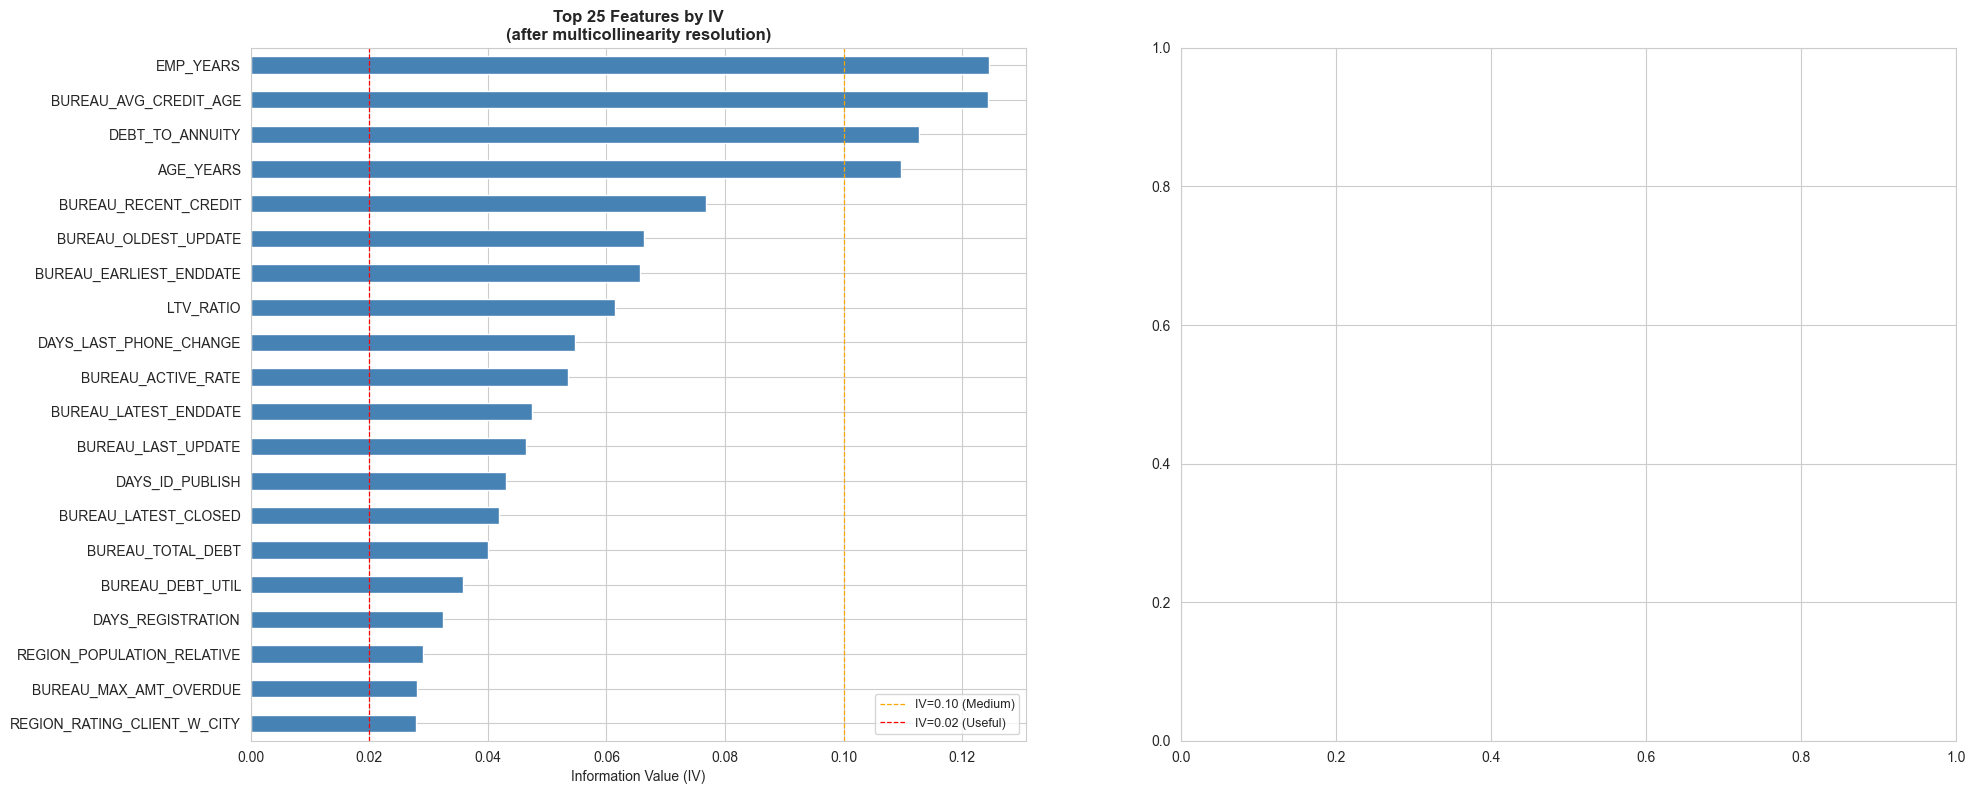

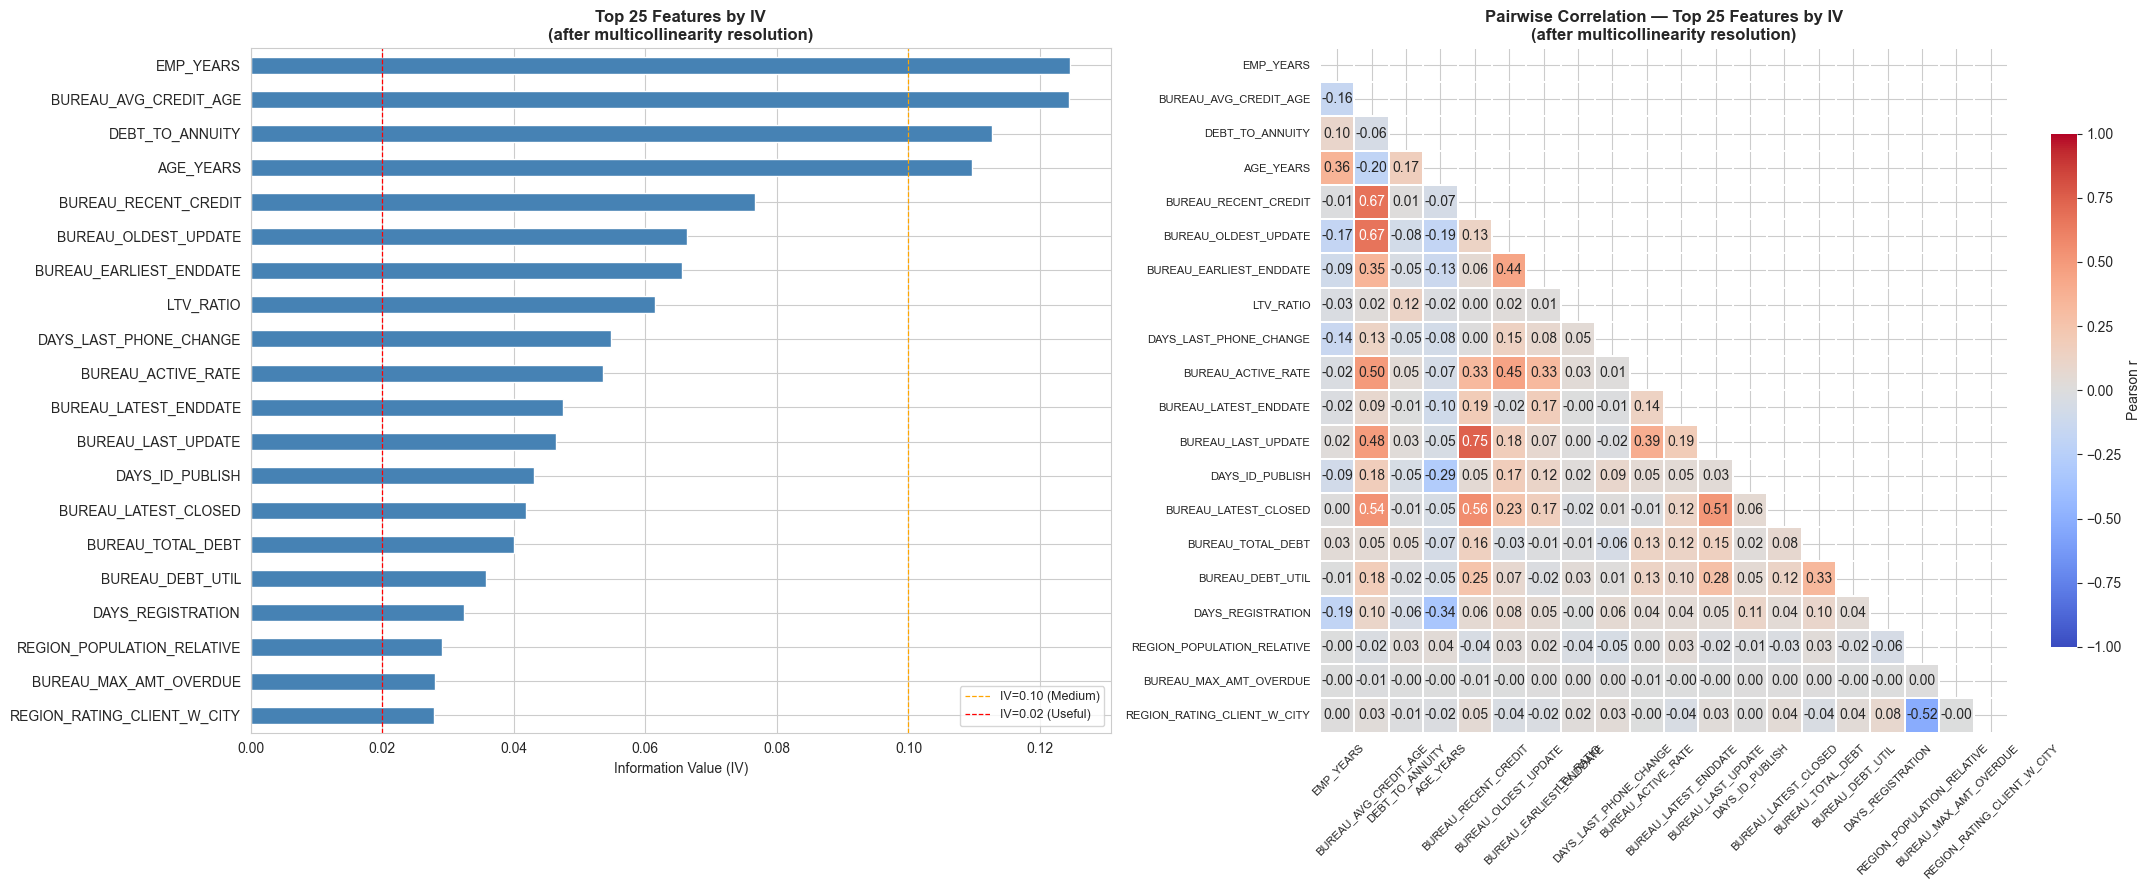

Remaining pairs with |r| > 0.7 in top-25: 1


,Feature_1,Feature_2,r
0,BUREAU_LAST_UPDATE,BUREAU_RECENT_CREDIT,0.75


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 3d: Updated correlation heatmap — top 25 features ranked by IV
# ─────────────────────────────────────────────────────────────────────────────

top25_iv = [f for f in iv_series.nlargest(35).index if f in train_df.columns][:25]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Left: IV bar chart
ax = axes[0]
iv_series[top25_iv].sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 25 Features by IV\n(after multicollinearity resolution)', fontsize=12, fontweight='bold')
ax.set_xlabel('Information Value (IV)')
ax.axvline(0.1,  color='orange', linestyle='--', linewidth=0.9, label='IV=0.10 (Medium)')
ax.axvline(0.02, color='red',    linestyle='--', linewidth=0.9, label='IV=0.02 (Useful)')
ax.legend(fontsize=9)

# Right: pairwise correlation heatmap
ax2 = axes[1]
corr_top25 = train_df[top25_iv].corr()
mask = np.triu(np.ones_like(corr_top25, dtype=bool))
sns.heatmap(corr_top25, mask=mask, ax=ax2, cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.3,
            cbar_kws={'label': 'Pearson r', 'shrink': 0.75})
ax2.set_title('Pairwise Correlation — Top 25 Features by IV\n(after multicollinearity resolution)',
              fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('correlation_heatmap_post_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

# Sanity check — any remaining pairs > 0.7?
upper = corr_top25.where(np.triu(np.ones(corr_top25.shape), k=1).astype(bool))
remaining = [(c, i, round(upper.loc[i, c], 3))
             for c in upper.columns for i in upper.index
             if abs(upper.loc[i, c]) > 0.7]
print(f"Remaining pairs with |r| > 0.7 in top-25: {len(remaining)}")
if remaining:
    display(pd.DataFrame(remaining, columns=['Feature_1', 'Feature_2', 'r'])
            .sort_values('r', key=abs, ascending=False))

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 3e: Generate Excel multicollinearity report with actual IV values
# ─────────────────────────────────────────────────────────────────────────────

# Persist the final iv_dict (now includes ratio features) so the report
# generator can read actual IV scores for every feature row.
with open('iv_scores.json', 'w') as f:
    json.dump(iv_dict, f, indent=2)

import subprocess, sys
result = subprocess.run(
    [sys.executable, 'generate_multicollinearity_report.py'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

print("\nFinal cleaned dataframe shape:", train_df.shape)
print("\nColumn list:")
display(pd.DataFrame({
    'Column': train_df.columns.tolist(),
    'Dtype':  train_df.dtypes.astype(str).tolist(),
    'IV':     [round(iv_dict.get(c, float('nan')), 4) for c in train_df.columns],
    'IV Strength': [iv_strength(iv_dict.get(c, 0)) if c in iv_dict else '—'
                    for c in train_df.columns],
}))

Loaded IV scores for 102 features from iv_scores.json
Saved: IS453_Multicollinearity_Feature_Report.xlsx
  Sheet 1 - 72 data rows (incl. group headers)
  Sheet 2 - 7 feature extraction proposals
  Sheet 3 - Summary statistics


Final cleaned dataframe shape: (138917, 80)

Column list:


,Column,Dtype,IV,IV Strength
0,SK_ID_CURR,int64,NaN,—
1,TARGET,int64,NaN,—
2,FLAG_OWN_REALTY,object,NaN,—
3,CNT_CHILDREN,int64,0.00,Useless
4,AMT_INCOME_TOTAL,float64,0.00,Useless
5,NAME_TYPE_SUITE,object,NaN,—
6,NAME_INCOME_TYPE,object,NaN,—
7,NAME_EDUCATION_TYPE,object,NaN,—
8,NAME_FAMILY_STATUS,object,NaN,—
9,NAME_HOUSING_TYPE,object,NaN,—


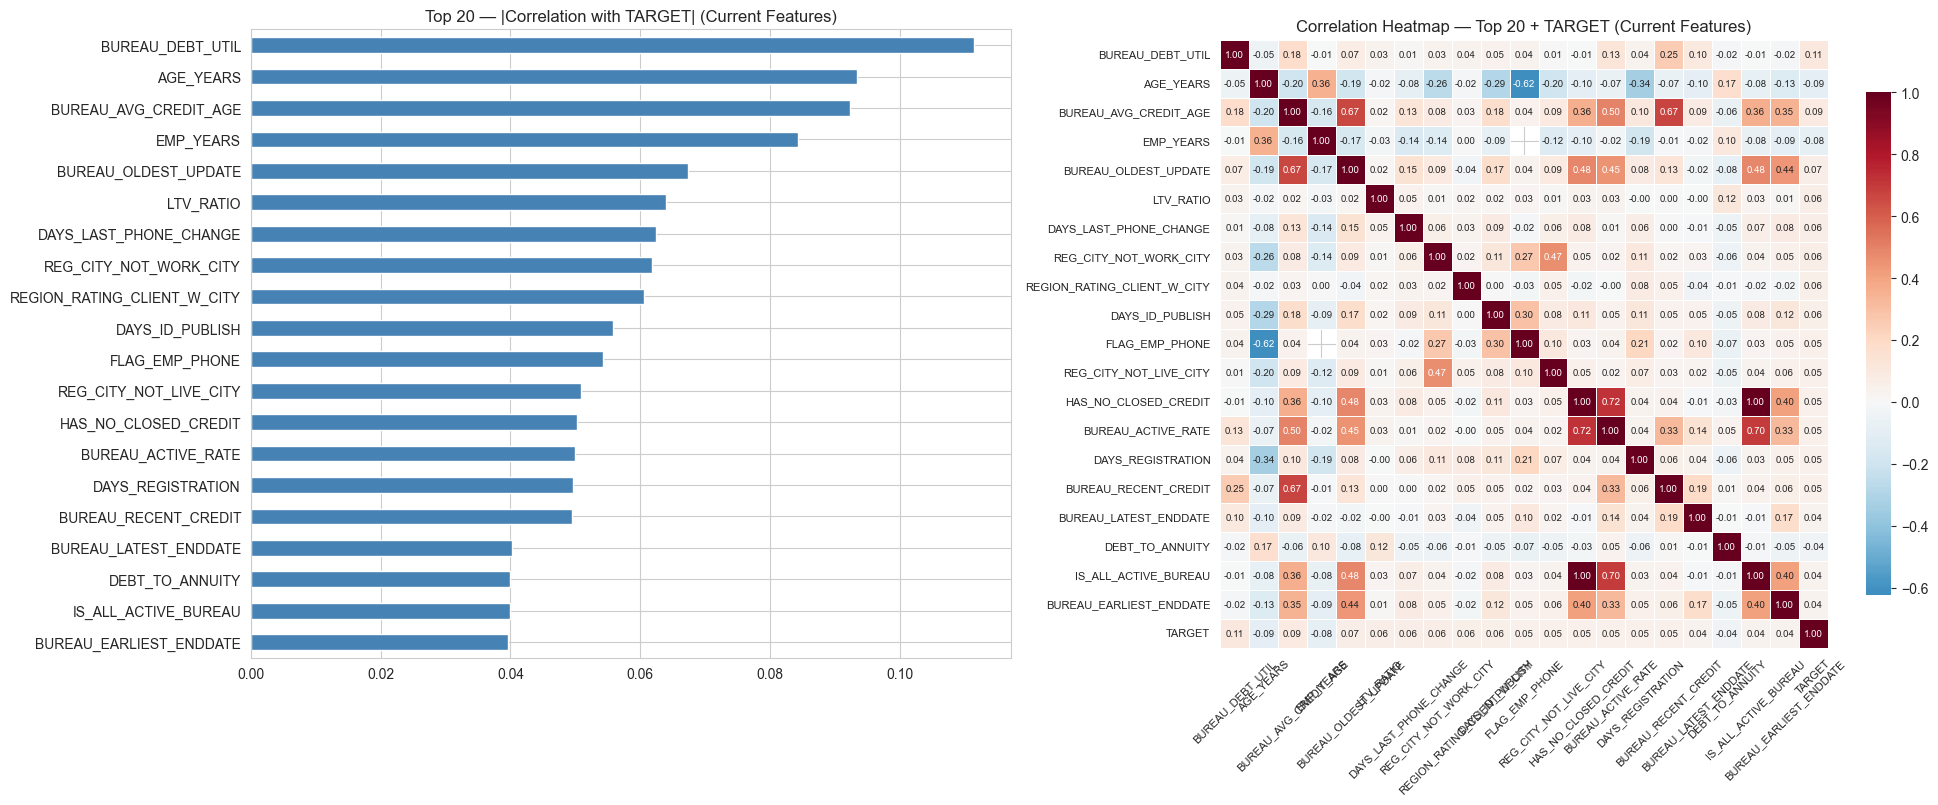

In [36]:
# Heatmap — top-20 TARGET-correlated features (safe after column drops)
num_cols_current = train_df.select_dtypes(include='number').columns.tolist()
num_cols_current = [c for c in num_cols_current if c != 'SK_ID_CURR']

target_corr_current = (
    train_df[num_cols_current].corr()['TARGET']
    .drop('TARGET').abs().sort_values(ascending=False)
)
top20_current = target_corr_current.head(20).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Bar chart
target_corr_current.head(20).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 — |Correlation with TARGET| (Current Features)')

# Heatmap
sns.heatmap(train_df[top20_current + ['TARGET']].corr(),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], square=True, linewidths=0.5,
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Heatmap — Top 20 + TARGET (Current Features)')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

In [37]:
train_df.shape

(138917, 80)

In [ ]:
##final shape before WOE
merged_df.shape

(173647, 83)